In [1]:
import glob
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import os



files = sorted(glob.glob("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/NLDAS_FORA0125_H.*.nc.SUB.nc4"))[:]   # 1 year will be 8640, all years will be 9640
#print(f"Found {len(files)} files")

print(len(files))


96432


In [2]:
#file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/NLDAS_FORA0125_H.A20140101.0000.020.nc.SUB.nc4"
file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/NLDAS_FORA0125_H.A20140101.0000.020.nc.SUB.nc4"

ds = xr.open_dataset(file)

ds

<xarray.Dataset> Size: 5kB
Dimensions:    (time: 1, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 8B 2014-01-01
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    Tair       (time, lat, lon) float32 576B ...
    Qair       (time, lat, lon) float32 576B ...
    PSurf      (time, lat, lon) float32 576B ...
    Wind_E     (time, lat, lon) float32 576B ...
    Wind_N     (time, lat, lon) float32 576B ...
    LWdown     (time, lat, lon) float32 576B ...
    Rainf      (time, lat, lon) float32 576B ...
    SWdown     (time, lat, lon) float32 576B ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 1.9.8 (https://mpi...
    Conventions:            CF-1.6
    history:                created on date: 2021-04-13T12:42:34
    institution:            NASA GSFC
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L34RS:          'Created by L34RS v1.4.4 @ NASA GES DISC on March...
    CDO:                    Climate Data Operators version 1.9.8 (https://mpi...

In [3]:
data_dir = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024"

test_files = sorted(glob.glob(os.path.join(data_dir, "NLDAS_FORA0125_H.A201401*.nc.SUB.nc4")))

ds_test = xr.open_mfdataset(test_files, combine="by_coords",parallel=True, chunks={"time": 24})

print(ds_test)
print(ds_test["Rainf"])

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 744, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2014-01-01 ... 2014-01-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 12kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    Tair       (time, lat, lon) float32 429kB dask.array<chunksize=(1, 12, 12), meta=np.ndarray>
    Qair       (time, lat, lon) float32 429kB dask.array<chunksize=(1, 12, 12), meta=np.ndarray>
    PSurf      (time, lat, lon) float32 429kB dask.array<chunksize=(1, 12, 12), meta=np.ndarray>
    Wind_E     (time, lat, lon) float32 429kB dask.array<chunksize=(1, 12, 12), meta=np.ndarray>
    Wind_N     (time, lat, lon) float32 429kB dask.array<chunksize=(1, 12, 12), meta=np.ndarray>
    LWdown     (time, lat, lon) float32 

In [4]:
# reading test month
file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/yearly_merged/met_2014.nc"

ds = xr.open_dataset(file)

ds

<xarray.Dataset> Size: 41MB
Dimensions:    (time: 8760, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2014-01-01 ... 2014-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 140kB ...
    Tair       (time, lat, lon) float32 5MB ...
    Qair       (time, lat, lon) float32 5MB ...
    PSurf      (time, lat, lon) float32 5MB ...
    Wind_E     (time, lat, lon) float32 5MB ...
    Wind_N     (time, lat, lon) float32 5MB ...
    LWdown     (time, lat, lon) float32 5MB ...
    Rainf      (time, lat, lon) float32 5MB ...
    SWdown     (time, lat, lon) float32 5MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 07:56:54 2026: cdo -O mergetime NLDAS_...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L34RS:          'Created by L34RS v1.4.4 @ NASA GES DISC on March...
    CDO:                    Climate Data Operators version 2.5.0 (https://mpi...

In [5]:
print(ds.time.min().values)
print(ds.time.max().values)
print(list(ds.data_vars))

print(ds["Rainf"])
print(ds["Rainf"].shape)
print(ds["Rainf"].attrs)

2014-01-01T00:00:00.000000000
2014-12-31T23:00:00.000000000
['time_bnds', 'Tair', 'Qair', 'PSurf', 'Wind_E', 'Wind_N', 'LWdown', 'Rainf', 'SWdown']
<xarray.DataArray 'Rainf' (time: 8760, lat: 12, lon: 12)> Size: 5MB
[1261440 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 70kB 2014-01-01 ... 2014-12-31T23:00:00
  * lat      (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon      (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Attributes:
    standard_name:  Total precipitation
    long_name:      Total precipitation
    units:          kg m-2
    cell_methods:   time: sum
    vmin:           0.0
    vmax:           7.1906
(8760, 12, 12)
{'standard_name': 'Total precipitation', 'long_name': 'Total precipitation', 'units': 'kg m-2', 'cell_methods': 'time: sum', 'vmin': np.float32(0.0), 'vmax': np.float32(7.1906)}


In [6]:
import xarray as xr

ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc")

ds


<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Rainf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:07 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L34RS:          'Created by L34RS v1.4.4 @ NASA GES DISC on March...
    CDO:                    Climate Data Operators version 2.5.0 (https://mpi...

In [7]:

print(ds.time.size)      # should be 96432
print(ds.time.min().values)
print(ds.time.max().values)
print(ds["Rainf"].shape)

96432
2014-01-01T00:00:00.000000000
2024-12-31T23:00:00.000000000
(96432, 12, 12)


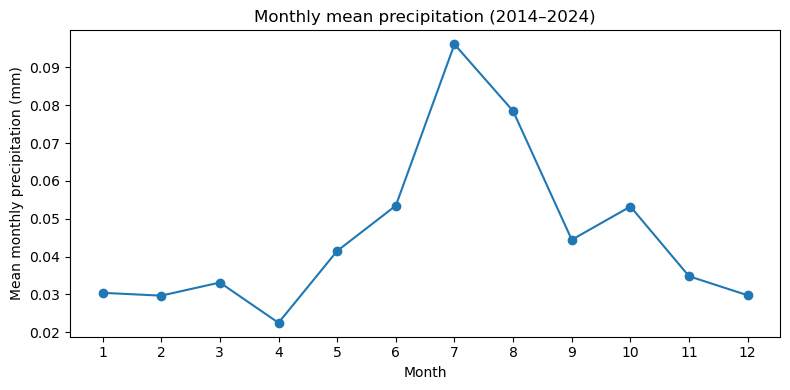

In [8]:
import xarray as xr
import matplotlib.pyplot as plt

# open your final file
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc")

# spatial mean (optional but recommended for clean plot)
rain = ds["Rainf"].mean(dim=["lat", "lon"])

# monthly climatology
monthly = rain.groupby("time.month").mean(dim="time")

# plot
plt.figure(figsize=(8,4))
plt.plot(monthly["month"], monthly.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Mean monthly precipitation (mm)")
plt.title("Monthly mean precipitation (2014–2024)")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

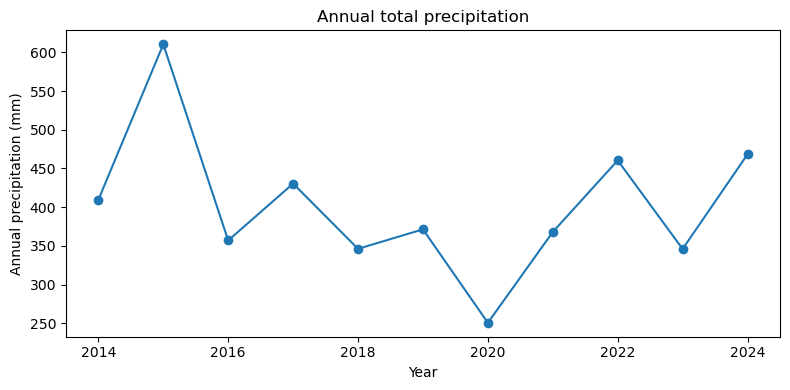

In [9]:
annual_total = rain.groupby("time.year").sum(dim="time")

plt.figure(figsize=(8,4))
plt.plot(annual_total["year"], annual_total.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm)")
plt.title("Annual total precipitation")
plt.tight_layout()
plt.show()

In [10]:
# check directory size in bash
#du -sh /projects/battobrah@xsede.org/NLDAS_data_2014_2024

In [13]:
import xarray as xr

fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"

ds = xr.open_dataset(fp, decode_times=False)

print(ds)

<xarray.Dataset> Size: 33MB
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * t        (t) float64 257kB 0.0 1.0 2.0 3.0 ... 3.212e+04 3.213e+04 3.213e+04
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Data variables:
    precip   (t, lat, lon) float32 33MB ...


In [14]:
import pandas as pd

ds = ds.assign_coords(t=pd.date_range(start="2014-01-01", periods=ds.sizes["t"], freq="3h"))

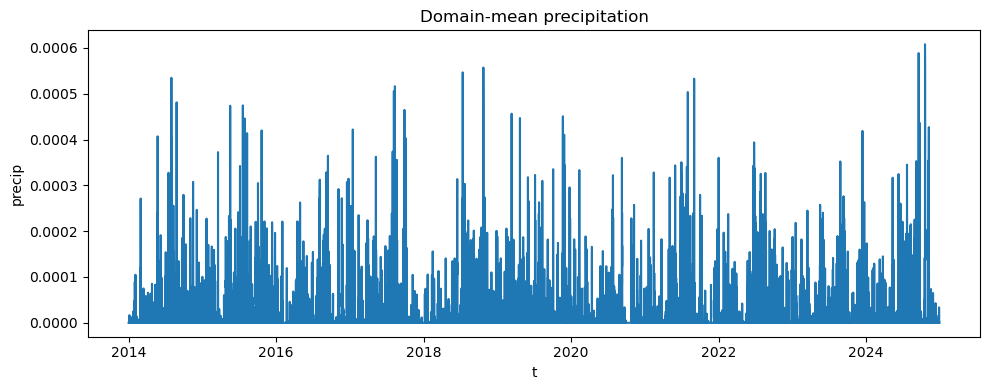

In [15]:
import matplotlib.pyplot as plt

da = ds["precip"]

ts = da.mean(dim=("lat", "lon"))

plt.figure(figsize=(10,4))
ts.plot()
plt.title("Domain-mean precipitation")
plt.tight_layout()
plt.show()

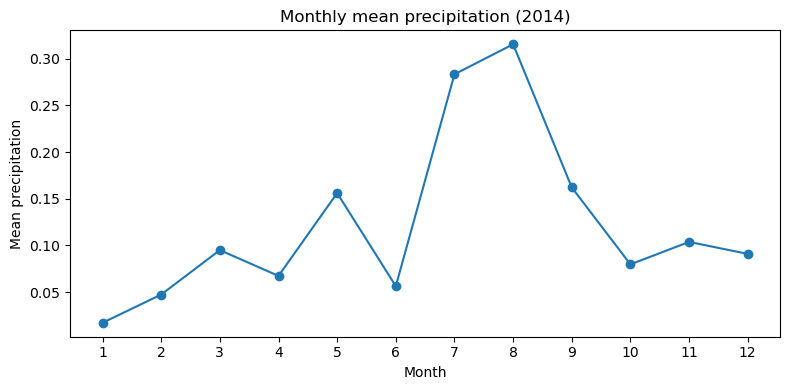

In [16]:
da = ds["precip"]*10800

da_2014 = da.sel(t="2014")
ts = da_2014.mean(dim=("lat","lon"))
monthly_2014 = ts.groupby("t.month").mean()
#monthly_total = ts.groupby("t.month").sum()
#plot
plt.figure(figsize=(8,4))
plt.plot(monthly_2014["month"], monthly_2014.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Mean precipitation")
plt.title("Monthly mean precipitation (2014)")
plt.xticks(range(1,13))



plt.tight_layout()
plt.show()

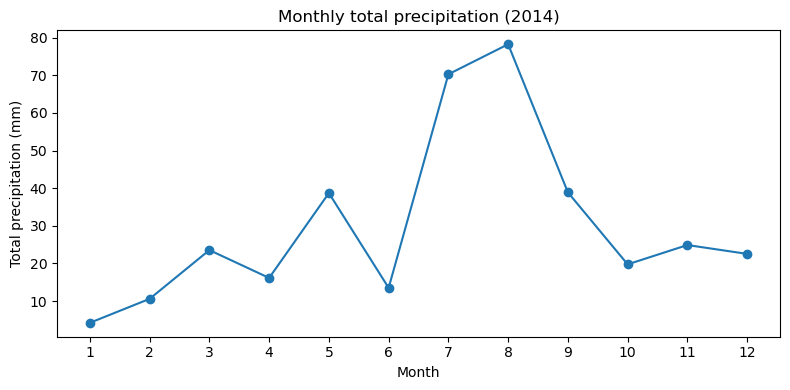

In [17]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"

ds = xr.open_dataset(fp, decode_times=False)
ds = ds.assign_coords(t=pd.date_range(start="2014-01-01", periods=ds.sizes["t"], freq="3h"))

da = ds["precip"] * 10800   # convert mm/s → mm per timestep (3 hr)

da_2014 = da.sel(t="2014")

ts = da_2014.mean(dim=("lat","lon"))
monthly_total = ts.groupby("t.month").sum()

plt.figure(figsize=(8,4))
plt.plot(monthly_total["month"], monthly_total.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total precipitation (mm)")
plt.title("Monthly total precipitation (2014)")

plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

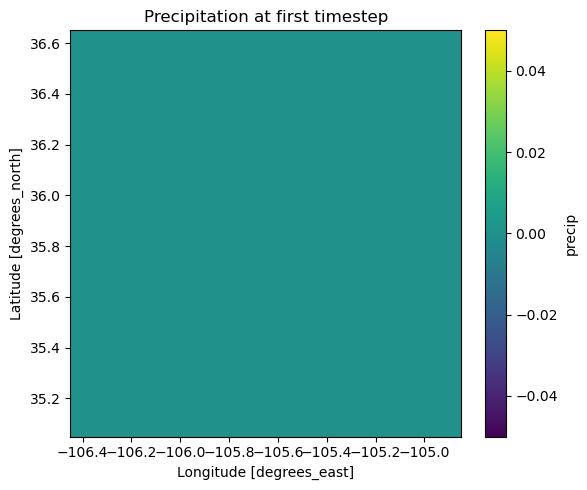

In [20]:
plt.figure(figsize=(6,5))
da.isel(t=0).plot()
plt.title("Precipitation at first timestep")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

ds["t"] = pd.date_range(start="2014-01-01",periods=ds.sizes["t"],freq="3h")

da = ds["precip"]* 10800

ts = da.mean(dim=("lat","lon"))


In [25]:
# annual totals
annual = ts.groupby("t.year").sum()

print(annual)

<xarray.DataArray 'precip' (year: 11)> Size: 44B
array([361.49316, 516.23413, 368.9358 , 489.01855, 364.75952, 452.52417,
       288.3938 , 408.4453 , 427.8623 , 363.5503 , 476.10425],
      dtype=float32)
Coordinates:
  * year     (year) int64 88B 2014 2015 2016 2017 2018 ... 2021 2022 2023 2024
Attributes:
    long_name:  precip


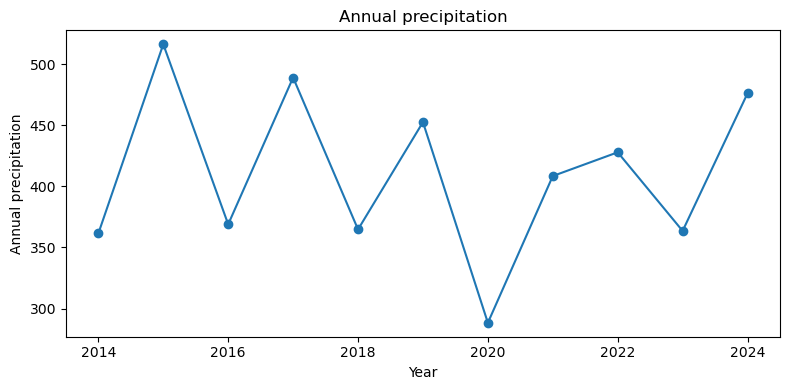

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(annual["year"], annual.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Annual precipitation")
plt.title("Annual precipitation")
plt.tight_layout()
plt.show()

In [27]:
annual_mean = annual.mean()

print(annual_mean)

<xarray.DataArray 'precip' ()> Size: 4B
array(410.66556, dtype=float32)
Attributes:
    long_name:  precip


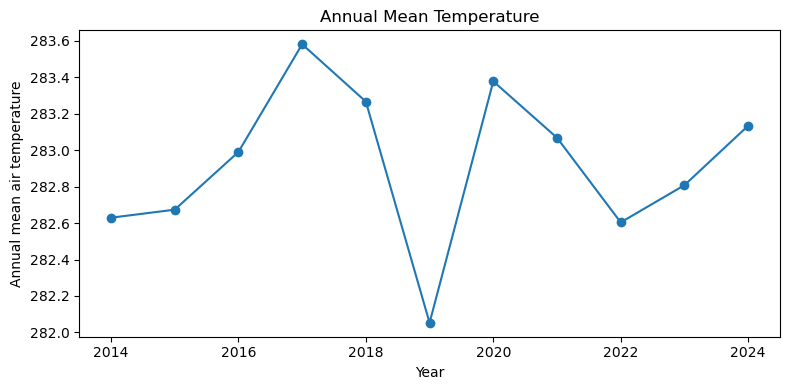

In [28]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair.nc"

ds = xr.open_dataset(fp, decode_times=False)

# assign proper datetime coordinate
ds["t"] = pd.date_range(start="2014-01-01",periods=ds.sizes["t"],freq="3h")

# temperature variable
da = ds["tair"]

# domain-mean temperature time series
ts = da.mean(dim=("lat", "lon"))

# annual mean temperature
annual = ts.groupby("t.year").mean()

# plot
plt.figure(figsize=(8,4))
plt.plot(annual["year"], annual.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Annual mean air temperature")
plt.title("Annual Mean Temperature")
plt.tight_layout()
plt.show()

<xarray.DataArray 'tair' (season: 4)> Size: 16B
array([273.229  , 292.74423, 281.61813, 283.9231 ], dtype=float32)
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    long_name:  tair


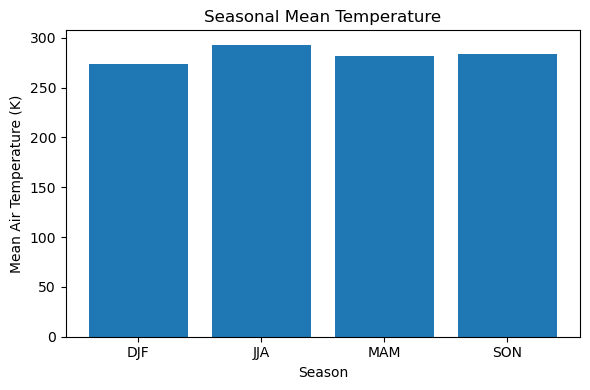

In [29]:

fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair.nc"

ds = xr.open_dataset(fp, decode_times=False)

# assign datetime
ds["t"] = pd.date_range(start="2014-01-01", periods=ds.sizes["t"], freq="3h")
da = ds["tair"]

# domain mean
ts = da.mean(dim=("lat", "lon"))

# seasonal mean
seasonal = ts.groupby("t.season").mean()

print(seasonal)

# plot
plt.figure(figsize=(6,4))
plt.bar(seasonal["season"], seasonal.values)

plt.xlabel("Season")
plt.ylabel("Mean Air Temperature (K)")
plt.title("Seasonal Mean Temperature")
plt.tight_layout()
plt.show()

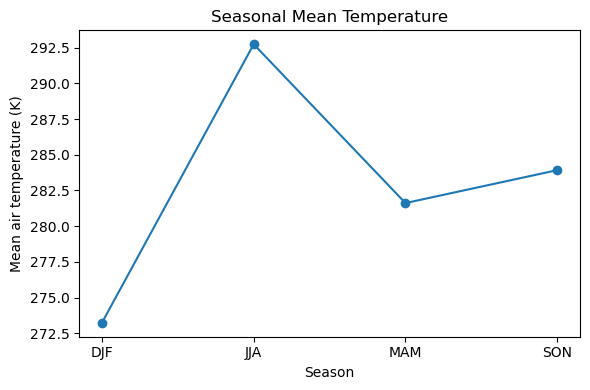

In [30]:
plt.figure(figsize=(6,4))

plt.plot(seasonal["season"].values, seasonal.values, marker="o")

plt.xlabel("Season")
plt.ylabel("Mean air temperature (K)")
plt.title("Seasonal Mean Temperature")

plt.tight_layout()
plt.show()

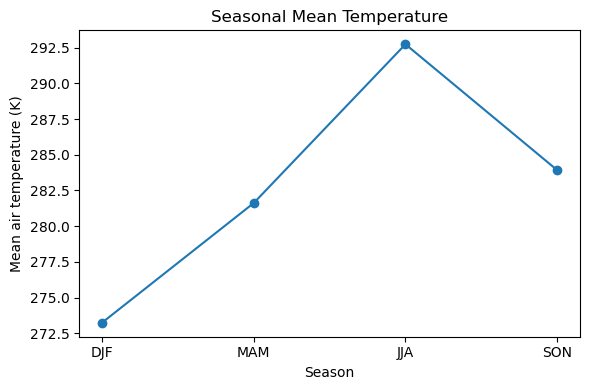

In [31]:
seasonal = ts.groupby("t.season").mean()
seasonal = seasonal.sel(season=["DJF","MAM","JJA","SON"])

plt.figure(figsize=(6,4))
plt.plot(seasonal["season"].values, seasonal.values, marker="o")

plt.xlabel("Season")
plt.ylabel("Mean air temperature (K)")
plt.title("Seasonal Mean Temperature")

plt.tight_layout()
plt.show()

In [32]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# 1. Open NLDAS
# -------------------------
ds_nldas = xr.open_dataset(
    "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc"
)

# -------------------------
# 2. Open HydroBlocks with decode_times=False
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)

# assign proper datetime coordinate to t
ds_hb = ds_hb.assign_coords(
    t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h")
)

# -------------------------
# 3. Spatial means
# -------------------------
rain_nldas = ds_nldas["Rainf"].mean(dim=["lat", "lon"])

# check HydroBlocks dimensions first
print(ds_hb)

<xarray.Dataset> Size: 33MB
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * t        (t) datetime64[us] 257kB 2014-01-01 ... 2024-12-29T21:00:00
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Data variables:
    precip   (t, lat, lon) float32 33MB ...


In [33]:
print(ds_hb["precip"])
print(ds_hb["precip"].dims)

rain_hb = ds_hb["precip"].mean(dim=["lat", "lon"])
#rain_hb = ds_hb["precip"].mean(dim=["y", "x"])
#rain_hb = ds_hb["precip"].mean(dim="hru")

<xarray.DataArray 'precip' (t: 32128, lat: 16, lon: 16)> Size: 33MB
[8224768 values with dtype=float32]
Coordinates:
  * t        (t) datetime64[us] 257kB 2014-01-01 ... 2024-12-29T21:00:00
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Attributes:
    long_name:  precip
('t', 'lat', 'lon')


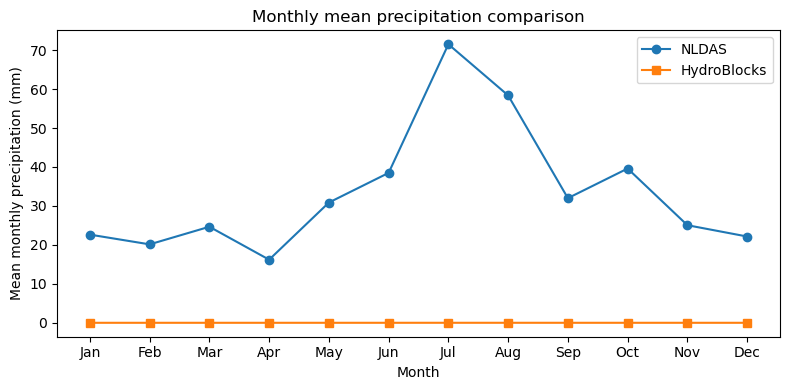

In [34]:
# monthly climatology
# monthly totals
monthly_nldas = rain_nldas.resample(time="MS").sum()
monthly_hb    = rain_hb.resample(t="MS").sum()

# monthly climatology
monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8, 4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Month")
plt.ylabel("Mean monthly precipitation (mm)")
plt.title("Monthly mean precipitation comparison")
plt.legend()
plt.tight_layout()
plt.show()

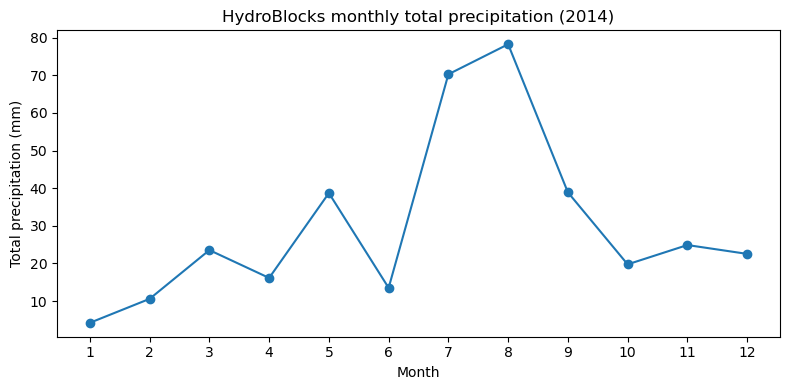

In [35]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"

ds = xr.open_dataset(fp, decode_times=False)
ds = ds.assign_coords(t=pd.date_range(start="2014-01-01", periods=ds.sizes["t"], freq="3h"))

# use precip, not tair
da = ds["precip"] * 10800   # convert rate to mm per 3-hour timestep

da_2014 = da.sel(t="2014")

ts = da_2014.mean(dim=("lat", "lon"))
monthly_total = ts.groupby("t.month").sum()

plt.figure(figsize=(8,4))
plt.plot(monthly_total["month"], monthly_total.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total precipitation (mm)")
plt.title("HydroBlocks monthly total precipitation (2014)")

plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

In [36]:
print(ds)
print(ds["precip"])
print(ds["precip"].attrs)

<xarray.Dataset> Size: 33MB
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * t        (t) datetime64[us] 257kB 2014-01-01 ... 2024-12-29T21:00:00
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Data variables:
    precip   (t, lat, lon) float32 33MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
<xarray.DataArray 'precip' (t: 32128, lat: 16, lon: 16)> Size: 33MB
array([[[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       ...,

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0.,

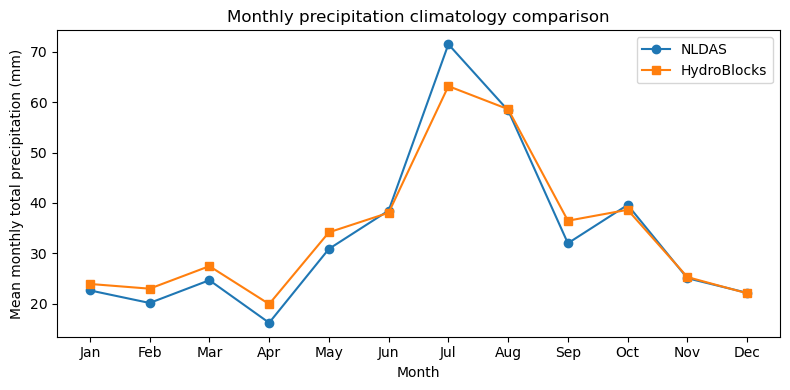

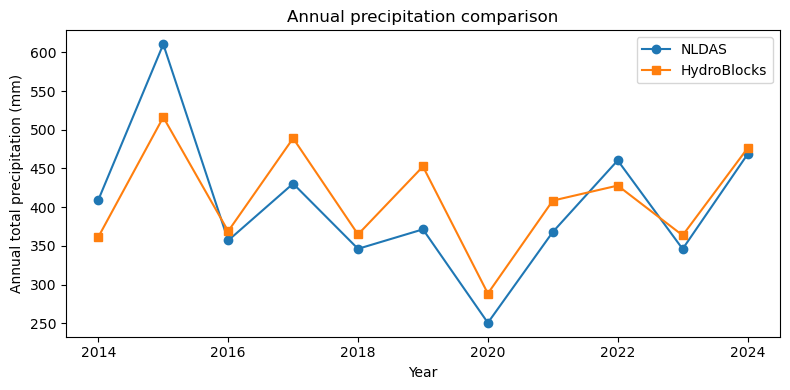

In [37]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# NLDAS
# -------------------------
ds_nldas = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc")

rain_nldas = ds_nldas["Rainf"].mean(dim=("lat", "lon"))   # already per timestep total

# -------------------------
# HydroBlocks
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)
ds_hb = ds_hb.assign_coords(t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h"))

# infer precip is a rate and convert to mm per 3-hour timestep
rain_hb = (ds_hb["precip"] * 10800).mean(dim=("lat", "lon"))

# -------------------------
# Monthly climatological total
# -------------------------
monthly_nldas = rain_nldas.resample(time="MS").sum()
monthly_hb    = rain_hb.resample(t="MS").sum()

monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8, 4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Month")
plt.ylabel("Mean monthly total precipitation (mm)")
plt.title("Monthly precipitation climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Annual total
# -------------------------
annual_nldas = rain_nldas.groupby("time.year").sum()
annual_hb    = rain_hb.groupby("t.year").sum()

plt.figure(figsize=(8, 4))
plt.plot(annual_nldas["year"], annual_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_hb["year"], annual_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Year")
plt.ylabel("Annual total precipitation (mm)")
plt.title("Annual precipitation comparison")
plt.legend()
plt.tight_layout()
plt.show()

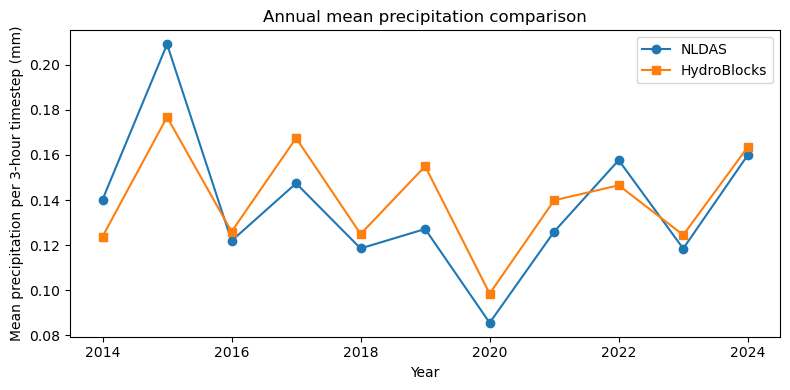

In [38]:
# convert NLDAS hourly totals to 3-hourly totals
rain_nldas_3h = rain_nldas.resample(time="3h").sum()

# annual mean precipitation per 3-hour timestep
annual_mean_nldas = rain_nldas_3h.groupby("time.year").mean()
annual_mean_hb    = rain_hb.groupby("t.year").mean()

plt.figure(figsize=(8, 4))
plt.plot(annual_mean_nldas["year"], annual_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_mean_hb["year"], annual_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Year")
plt.ylabel("Mean precipitation per 3-hour timestep (mm)")
plt.title("Annual mean precipitation comparison")
plt.legend()
plt.tight_layout()
plt.show()

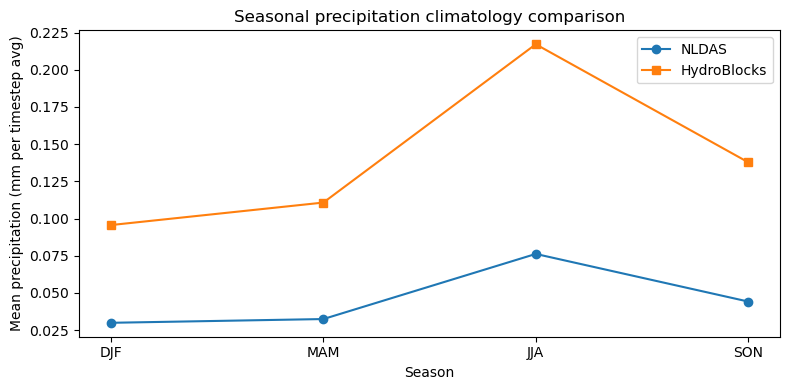

In [40]:
# -------------------------
# Seasonal climatological mean: timesteps
# -------------------------

# NLDAS
season_nldas = rain_nldas.groupby("time.season").mean()

# HydroBlocks
season_hb = rain_hb.groupby("t.season").mean()

# Ensure consistent season order
season_order = ["DJF", "MAM", "JJA", "SON"]

season_nldas = season_nldas.sel(season=season_order)
season_hb    = season_hb.sel(season=season_order)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(season_order, season_nldas.values, marker="o", label="NLDAS")
plt.plot(season_order, season_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Season")
plt.ylabel("Mean precipitation (mm per timestep avg)")
plt.title("Seasonal precipitation climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

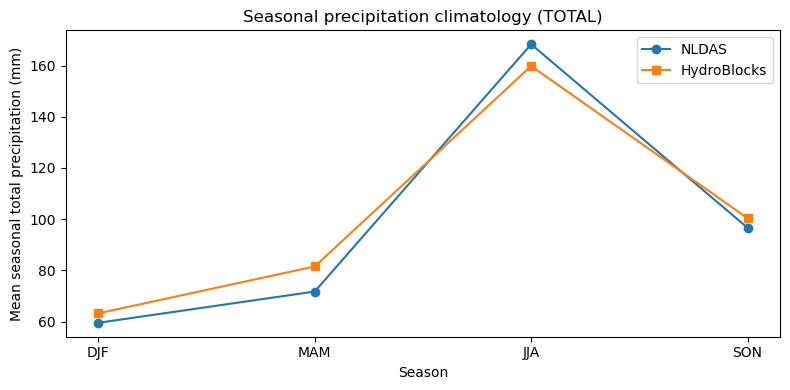

In [ ]:
# -------------------------
# Seasonal climatological TOTAL
# -------------------------

season_nldas = rain_nldas.resample(time="QS-DEC").sum().groupby("time.season").mean()
season_hb    = rain_hb.resample(t="QS-DEC").sum().groupby("t.season").mean()

season_nldas = season_nldas.sel(season=season_order)
season_hb    = season_hb.sel(season=season_order)

plt.figure(figsize=(8, 4))
plt.plot(season_order, season_nldas.values, marker="o", label="NLDAS")
plt.plot(season_order, season_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Season")
plt.ylabel("Mean seasonal total precipitation (mm)")
plt.title("Seasonal precipitation climatology (TOTAL)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# NLDAS (hourly)
# -------------------------
ds_nldas = xr.open_dataset(
    "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Tair_2014_2024.nc"
)

tair_nldas = ds_nldas["Tair"].mean(dim=("lat","lon"))

# -------------------------
# HydroBlocks (3-hourly)
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)
ds_hb = ds_hb.assign_coords(
    t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h")
)

tair_hb = ds_hb["tair"].mean(dim=("lat","lon"))

In [ ]:
print(ds_nldas["Tair"].attrs)
print(ds_hb["tair"].attrs)

{'standard_name': 'Near surface air temperature', 'long_name': '2-meter above ground Temperature', 'units': 'K', 'cell_methods': 'time: point', 'vmin': np.float32(241.06999), 'vmax': np.float32(298.72998)}
{'long_name': 'tair'}


In [ ]:
tair_nldas = tair_nldas - 273.15
tair_hb    = tair_hb - 273.15

In [ ]:
print(tair_nldas.min().values, tair_nldas.max().values)
print(tair_hb.min().values, tair_hb.max().values)

-14.535828 33.73462
-21.157745 34.442596


In [ ]:
diff = monthly_mean_hb - monthly_mean_nldas

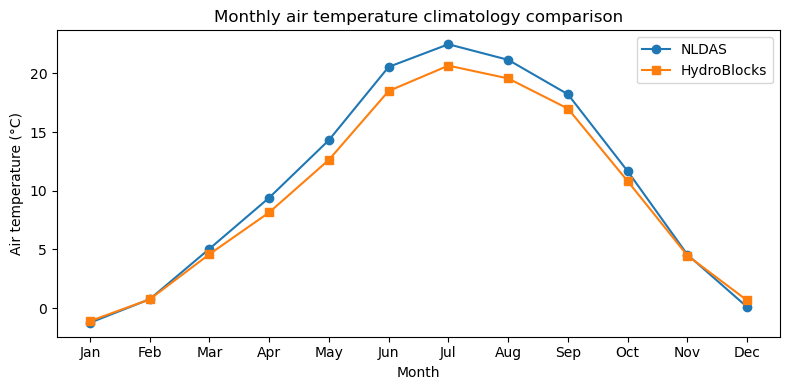

In [ ]:
# monthly mean (not sum!)
monthly_nldas = tair_nldas.resample(time="MS").mean()
monthly_hb    = tair_hb.resample(t="MS").mean()

monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8,4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")

plt.xlabel("Month")
plt.ylabel("Air temperature (°C)")
plt.title("Monthly air temperature climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

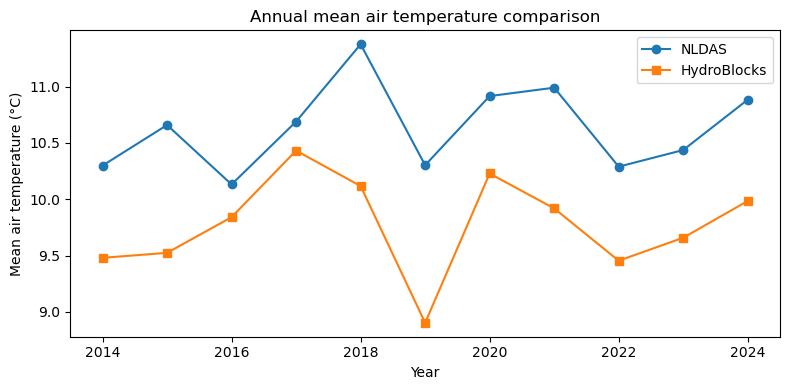

In [ ]:
annual_nldas = tair_nldas.groupby("time.year").mean()
annual_hb    = tair_hb.groupby("t.year").mean()

plt.figure(figsize=(8,4))
plt.plot(annual_nldas["year"], annual_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_hb["year"], annual_hb.values, marker="s", label="HydroBlocks")

plt.xlabel("Year")
plt.ylabel("Mean air temperature (°C)")
plt.title("Annual mean air temperature comparison")
plt.legend()
plt.tight_layout()
plt.show()

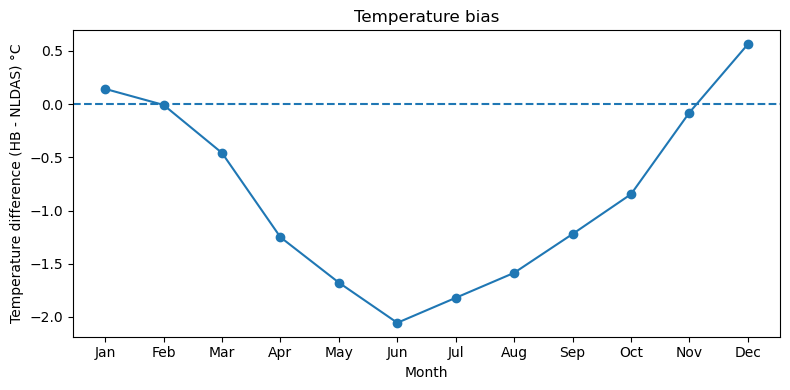

In [ ]:
diff = monthly_mean_hb - monthly_mean_nldas

plt.figure(figsize=(8,4))
plt.plot(months, diff.values, marker="o")

plt.axhline(0, linestyle="--")
plt.xlabel("Month")
plt.ylabel("Temperature difference (HB - NLDAS) °C")
plt.title("Temperature bias")
plt.tight_layout()
plt.show()

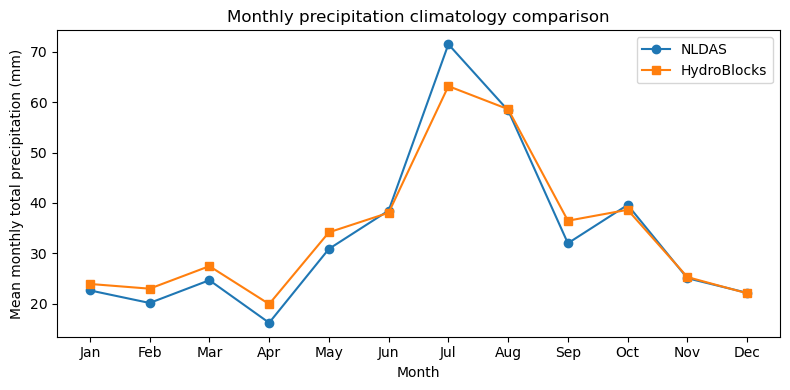

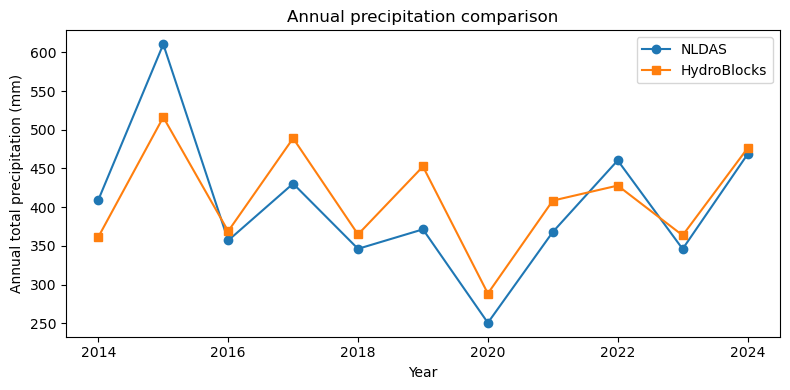

    year    NLDAS_mm  HydroBlocks_mm  HB_minus_NLDAS_mm  Percent_bias_%
0   2014  409.420013      361.489990         -47.930000      -11.710000
1   2015  610.479980      516.229980         -94.239998      -15.440000
2   2016  356.929993      368.940002          12.000000        3.360000
3   2017  430.399994      489.019989          58.619999       13.620000
4   2018  346.140015      364.760010          18.620001        5.380000
5   2019  371.299988      452.519989          81.230003       21.879999
6   2020  250.539993      288.390015          37.849998       15.110000
7   2021  367.890015      408.450012          40.560001       11.020000
8   2022  460.390015      427.859985         -32.520000       -7.060000
9   2023  345.950012      363.549988          17.600000        5.090000
10  2024  468.260010      476.100006           7.840000        1.670000

Full-period total precipitation (2014–2024)
NLDAS:       4417.70 mm
HydroBlocks: 4517.32 mm
Difference:  99.63 mm
Percent bias:2.26%


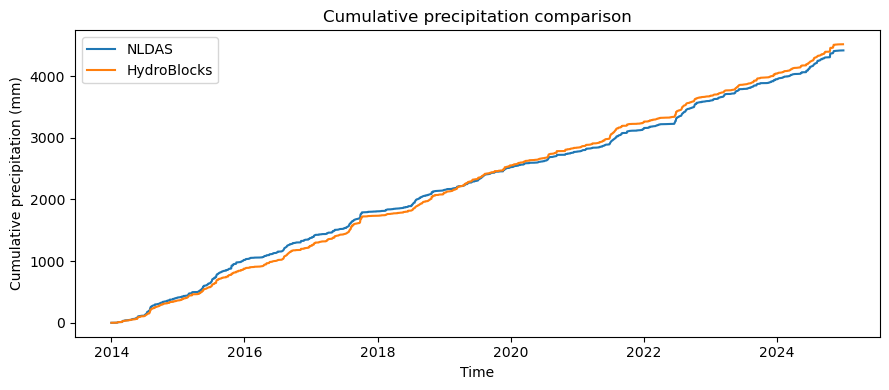

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# NLDAS
# -------------------------
ds_nldas = xr.open_dataset(
    "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc"
)

# domain-mean precipitation
rain_nldas = ds_nldas["Rainf"].mean(dim=("lat", "lon"))

# -------------------------
# HydroBlocks
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)
ds_hb = ds_hb.assign_coords(
    t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h")
)

# convert HydroBlocks precip rate to 3-hour accumulated amount
rain_hb = (ds_hb["precip"] * 10800).mean(dim=("lat", "lon"))

# -------------------------
# Monthly climatological total
# -------------------------
monthly_nldas = rain_nldas.resample(time="MS").sum()
monthly_hb    = rain_hb.resample(t="MS").sum()

monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8, 4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Month")
plt.ylabel("Mean monthly total precipitation (mm)")
plt.title("Monthly precipitation climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Annual total
# -------------------------
annual_nldas = rain_nldas.groupby("time.year").sum()
annual_hb    = rain_hb.groupby("t.year").sum()

plt.figure(figsize=(8, 4))
plt.plot(annual_nldas["year"], annual_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_hb["year"], annual_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Year")
plt.ylabel("Annual total precipitation (mm)")
plt.title("Annual precipitation comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Annual total table + percent bias
# -------------------------
annual_df = pd.DataFrame({
    "year": annual_nldas["year"].values,
    "NLDAS_mm": annual_nldas.values,
    "HydroBlocks_mm": annual_hb.values
})

annual_df["HB_minus_NLDAS_mm"] = annual_df["HydroBlocks_mm"] - annual_df["NLDAS_mm"]
annual_df["Percent_bias_%"] = 100 * annual_df["HB_minus_NLDAS_mm"] / annual_df["NLDAS_mm"]

print(annual_df.round(2))

# -------------------------
# Full-period total
# -------------------------
total_nldas = rain_nldas.sum()
total_hb    = rain_hb.sum()

print("\nFull-period total precipitation (2014–2024)")
print(f"NLDAS:       {float(total_nldas.values):.2f} mm")
print(f"HydroBlocks: {float(total_hb.values):.2f} mm")
print(f"Difference:  {float((total_hb - total_nldas).values):.2f} mm")
print(f"Percent bias:{float(((total_hb - total_nldas) / total_nldas * 100).values):.2f}%")

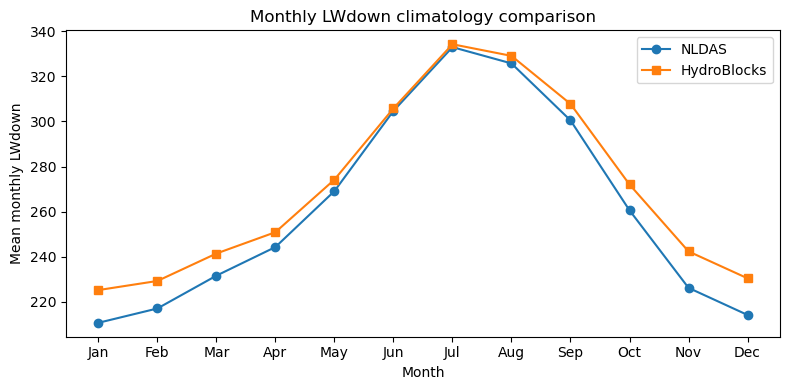

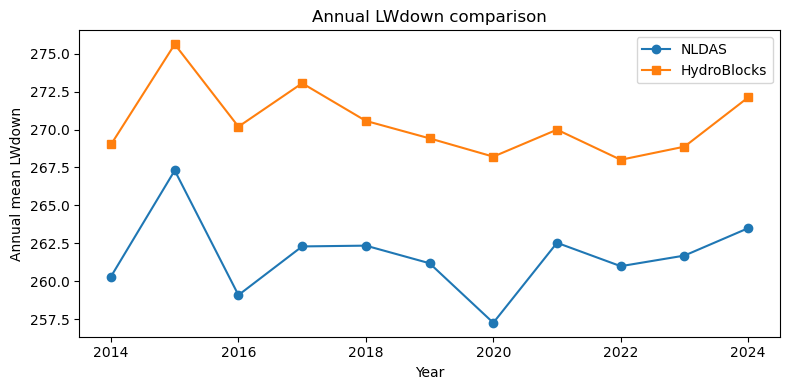

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# NLDAS
# -------------------------
ds_nldas = xr.open_dataset(
    "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/LWdown_2014_2024.nc"
)

# domain-mean LWdown
lw_nldas = ds_nldas["LWdown"].mean(dim=("lat", "lon"))

# -------------------------
# HydroBlocks
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/lwdown.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)
ds_hb = ds_hb.assign_coords(
    t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h")
)

# domain-mean LWdown
lw_hb = ds_hb["lwdown"].mean(dim=("lat", "lon"))

# -------------------------
# Monthly climatological mean
# -------------------------
monthly_nldas = lw_nldas.resample(time="MS").mean()
monthly_hb    = lw_hb.resample(t="MS").mean()

monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8, 4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Month")
plt.ylabel("Mean monthly LWdown")
plt.title("Monthly LWdown climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Annual mean
# -------------------------
annual_nldas = lw_nldas.groupby("time.year").mean()
annual_hb    = lw_hb.groupby("t.year").mean()

plt.figure(figsize=(8, 4))
plt.plot(annual_nldas["year"], annual_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_hb["year"], annual_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Year")
plt.ylabel("Annual mean LWdown")
plt.title("Annual LWdown comparison")
plt.legend()
plt.tight_layout()
plt.show()

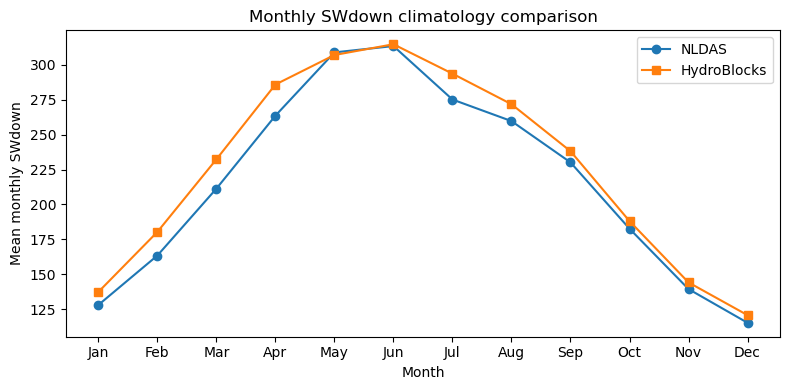

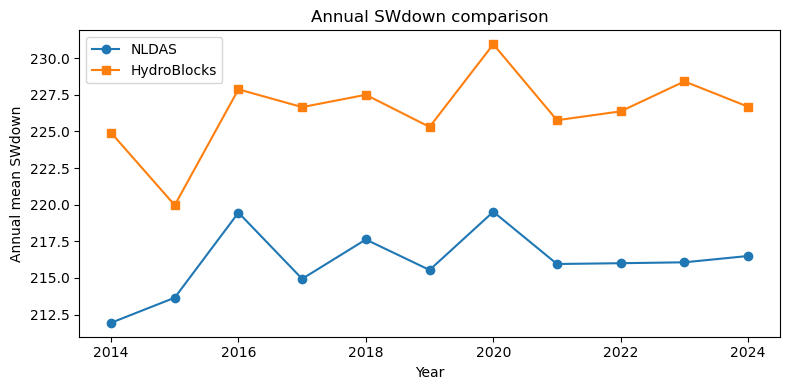

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# NLDAS
# -------------------------
ds_nldas = xr.open_dataset(
    "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/SWdown_2014_2024.nc"
)

# domain-mean SWdown
sw_nldas = ds_nldas["SWdown"].mean(dim=("lat", "lon"))

# -------------------------
# HydroBlocks
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/swdown.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)
ds_hb = ds_hb.assign_coords(
    t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h")
)

# domain-mean SWdown
sw_hb = ds_hb["swdown"].mean(dim=("lat", "lon"))

# -------------------------
# Monthly climatological mean
# -------------------------
monthly_nldas = sw_nldas.resample(time="MS").mean()
monthly_hb    = sw_hb.resample(t="MS").mean()

monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8, 4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Month")
plt.ylabel("Mean monthly SWdown")
plt.title("Monthly SWdown climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Annual mean
# -------------------------
annual_nldas = sw_nldas.groupby("time.year").mean()
annual_hb    = sw_hb.groupby("t.year").mean()

plt.figure(figsize=(8, 4))
plt.plot(annual_nldas["year"], annual_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_hb["year"], annual_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Year")
plt.ylabel("Annual mean SWdown")
plt.title("Annual SWdown comparison")
plt.legend()
plt.tight_layout()
plt.show()

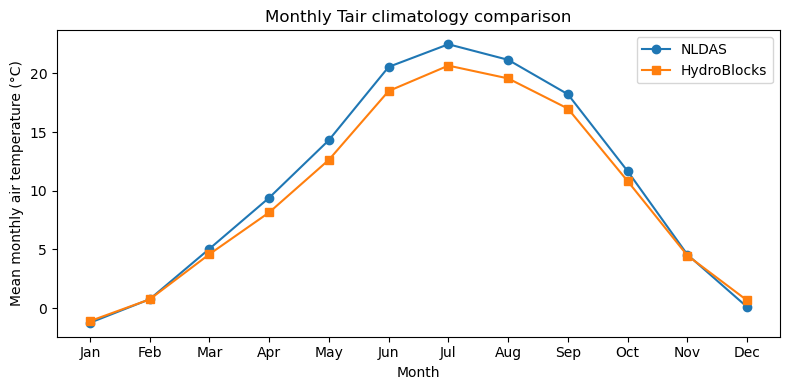

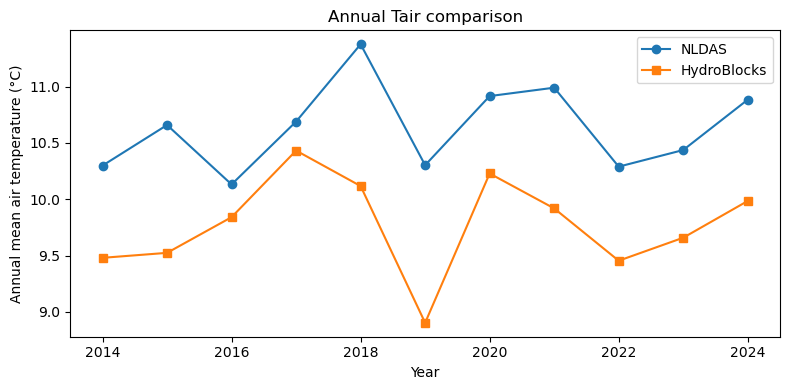

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# -------------------------
# NLDAS
# -------------------------
ds_nldas = xr.open_dataset(
    "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Tair_2014_2024.nc"
)

# domain-mean Tair
tair_nldas = ds_nldas["Tair"].mean(dim=("lat", "lon"))

# -------------------------
# HydroBlocks
# -------------------------
fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair.nc"

ds_hb = xr.open_dataset(fp, decode_times=False)
ds_hb = ds_hb.assign_coords(
    t=pd.date_range(start="2014-01-01", periods=ds_hb.sizes["t"], freq="3h")
)

# domain-mean Tair
tair_hb = ds_hb["tair"].mean(dim=("lat", "lon"))

# -------------------------
# Convert to Celsius for plotting
# -------------------------
tair_nldas_c = tair_nldas - 273.15
tair_hb_c    = tair_hb - 273.15

# -------------------------
# Monthly climatological mean
# -------------------------
monthly_nldas = tair_nldas_c.resample(time="MS").mean()
monthly_hb    = tair_hb_c.resample(t="MS").mean()

monthly_mean_nldas = monthly_nldas.groupby("time.month").mean()
monthly_mean_hb    = monthly_hb.groupby("t.month").mean()

months = [calendar.month_abbr[m] for m in monthly_mean_nldas["month"].values]

plt.figure(figsize=(8, 4))
plt.plot(months, monthly_mean_nldas.values, marker="o", label="NLDAS")
plt.plot(months, monthly_mean_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Month")
plt.ylabel("Mean monthly air temperature (°C)")
plt.title("Monthly Tair climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Annual mean
# -------------------------
annual_nldas = tair_nldas_c.groupby("time.year").mean()
annual_hb    = tair_hb_c.groupby("t.year").mean()

plt.figure(figsize=(8, 4))
plt.plot(annual_nldas["year"], annual_nldas.values, marker="o", label="NLDAS")
plt.plot(annual_hb["year"], annual_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Year")
plt.ylabel("Annual mean air temperature (°C)")
plt.title("Annual Tair comparison")
plt.legend()
plt.tight_layout()
plt.show()

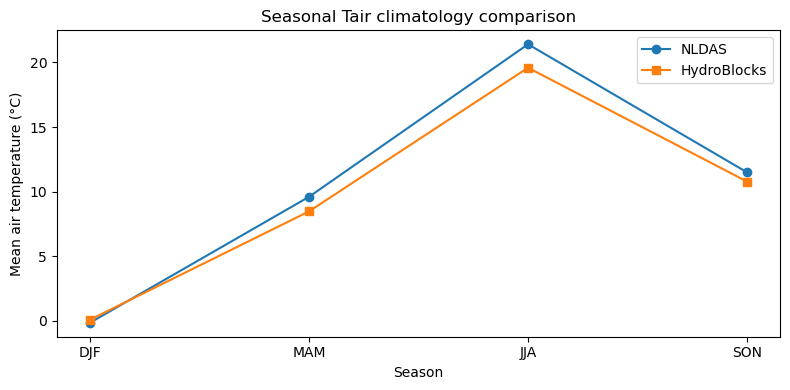

In [ ]:
# -------------------------
# Seasonal climatological mean (Tair)
# -------------------------

# NLDAS
season_nldas = tair_nldas_c.groupby("time.season").mean()

# HydroBlocks
season_hb = tair_hb_c.groupby("t.season").mean()

# Order seasons properly
season_order = ["DJF", "MAM", "JJA", "SON"]

season_nldas = season_nldas.sel(season=season_order)
season_hb    = season_hb.sel(season=season_order)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(season_order, season_nldas.values, marker="o", label="NLDAS")
plt.plot(season_order, season_hb.values, marker="s", label="HydroBlocks")
plt.xlabel("Season")
plt.ylabel("Mean air temperature (°C)")
plt.title("Seasonal Tair climatology comparison")
plt.legend()
plt.tight_layout()
plt.show()

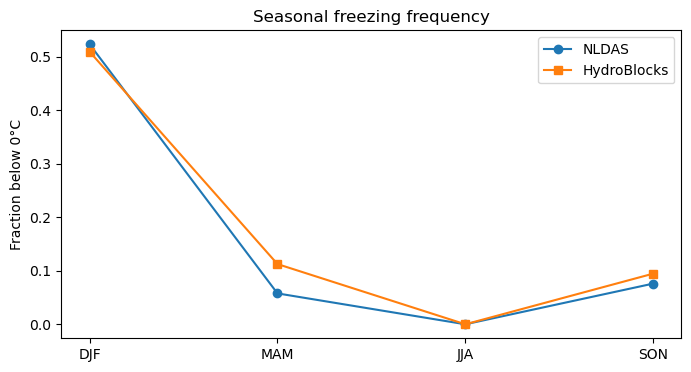

In [ ]:
freeze_nldas = (tair_nldas_c < 0).groupby("time.season").mean()
freeze_hb    = (tair_hb_c < 0).groupby("t.season").mean()

freeze_nldas = freeze_nldas.sel(season=["DJF","MAM","JJA","SON"])
freeze_hb    = freeze_hb.sel(season=["DJF","MAM","JJA","SON"])

plt.figure(figsize=(8,4))
plt.plot(["DJF","MAM","JJA","SON"], freeze_nldas, marker="o", label="NLDAS")
plt.plot(["DJF","MAM","JJA","SON"], freeze_hb, marker="s", label="HydroBlocks")
plt.ylabel("Fraction below 0°C")
plt.title("Seasonal freezing frequency")
plt.legend()
plt.show()

In [ ]:
import xarray as xr

fp0 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"
fp1 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_TairPlus1K/output_data/1/2016-01-01.nc"

ds0 = xr.open_dataset(fp0)
ds1 = xr.open_dataset(fp1)

print(ds0)
print(list(ds0.data_vars))

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
[]


In [ ]:
import netCDF4

fp0 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"

nc = netCDF4.Dataset(fp0)
print(nc.groups.keys())

dict_keys(['data', 'metadata'])


In [ ]:
import xarray as xr

ds0 = xr.open_dataset(fp0, group="data", engine="netcdf4")
ds1 = xr.open_dataset(fp1, group="data", engine="netcdf4")

In [ ]:
fsno0 = ds0["fsno"]
fsno1 = ds1["fsno"]

diff_fsno = fsno1 - fsno0

print("FSNO diff:",
      float(diff_fsno.min()),
      float(diff_fsno.max()),
      float(diff_fsno.mean()))

FSNO diff: -1.0 1.0 4.488887861953117e-05


In [ ]:
fsno0 = ds0["fsno"]
fsno1 = ds1["fsno"]

diff_fsno = fsno1 - fsno0

print("FSNO diff:",
      float(diff_fsno.min()),
      float(diff_fsno.max()),
      float(diff_fsno.mean()))

FSNO diff: -1.0 1.0 4.488887861953117e-05


In [ ]:
swe0 = ds0["swe"]
swe1 = ds1["swe"]

diff_swe = swe1 - swe0

print("SWE diff:",
      float(diff_swe.min()),
      float(diff_swe.max()),
      float(diff_swe.mean()))

SWE diff: -55.05743408203125 53.75787353515625 0.00598781555891037


In [ ]:
import xarray as xr
import pandas as pd

fp0 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"
fp1 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp__pp_MFSNO3p0/output_data/1/2016-01-01.nc"

# physics variables
ds0 = xr.open_dataset(fp0, group="data")
ds1 = xr.open_dataset(fp1, group="data")

# metadata
meta0 = xr.open_dataset(fp0, group="metadata")

print(meta0)
print(list(meta0.data_vars))

<xarray.Dataset> Size: 152kB
Dimensions:  (time: 8744, hru: 1000)
Coordinates:
  * time     (time) float64 70kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * hru      (hru) int32 4kB 0 1 2 3 4 5 6 7 ... 992 993 994 995 996 997 998 999
Data variables:
    date     (time) datetime64[ns] 70kB ...
    pct      (hru) float32 4kB ...
    area     (hru) float32 4kB ...
['date', 'pct', 'area']


In [ ]:
time_raw = meta0["time"]
print(time_raw)
print(time_raw.dtype)
print(time_raw.values[:5])

<xarray.DataArray 'time' (time: 8744)> Size: 70kB
array([9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36, 9.96921e+36,
       9.96921e+36], shape=(8744,))
Coordinates:
  * time     (time) float64 70kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
float64
[9.96920997e+36 9.96920997e+36 9.96920997e+36 9.96920997e+36
 9.96920997e+36]


In [ ]:
meta0 = xr.open_dataset(fp0, group="metadata")

print(meta0["date"])
print(meta0["date"].values[:5])

<xarray.DataArray 'date' (time: 8744)> Size: 70kB
[8744 values with dtype=datetime64[ns]]
Coordinates:
  * time     (time) float64 70kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
['2016-01-01T00:00:00.000000000' '2016-01-01T03:00:00.000000000'
 '2016-01-01T06:00:00.000000000' '2016-01-01T09:00:00.000000000'
 '2016-01-01T12:00:00.000000000']


In [ ]:
ds0 = ds0.assign_coords(time=time)
ds1 = ds1.assign_coords(time=time)

In [ ]:
import pandas as pd

time = pd.to_datetime(meta0["date"].values)

In [ ]:
import xarray as xr


fsno0 = ds0["fsno"]
fsno1 = ds1["fsno"]

In [ ]:
time = ds0["time"]

# Spring months
spring = (time.dt.month >= 3) & (time.dt.month <= 5)

fsno0_spring = fsno0.sel(time=spring)
fsno1_spring = fsno1.sel(time=spring)

In [ ]:
diff = fsno1_spring - fsno0_spring

print("Spring FSNO diff stats:")
print("min:", float(diff.min()))
print("max:", float(diff.max()))
print("mean:", float(diff.mean()))

Spring FSNO diff stats:
min: -1.0
max: 1.0
mean: -0.03494047001004219


In [ ]:
diff = fsno1_spring - fsno0_spring
print(float(diff.min()), float(diff.max()), float(diff.mean()))

-1.0 1.0 -0.03494047001004219


In [41]:
print(ds_hb)
print(list(ds_hb.data_vars))

<xarray.Dataset> Size: 33MB
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * t        (t) datetime64[us] 257kB 2014-01-01 ... 2024-12-29T21:00:00
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Data variables:
    precip   (t, lat, lon) float32 33MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
['precip']


In [42]:
print(ds_hb["precip"])
print(ds_hb["precip"].attrs)
print(float(ds_hb["precip"].mean()))
print(float(ds_hb["precip"].max()))

<xarray.DataArray 'precip' (t: 32128, lat: 16, lon: 16)> Size: 33MB
array([[[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       ...,

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]]], shape=(32128, 16, 16), dtype=float32)
Coordinates:
  * t        (t) datetime64[us] 257kB 2014-01-01 ... 2024-12-29T21:00:00
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Attributes:
    long_name:  precip
{'long_name': 'precip'}
1.3018876416026615e-0

In [46]:
import xarray as xr
import numpy as np

# HydroBlocks output
ds = xr.open_dataset("your_HB_output.nc")

# Variables (adjust names if needed)
rain = ds['rainf']     # rainfall
snow = ds['snowf']     # snowfall
precip = rain + snow

# seasonal selection (DJF or NDJFM)
winter = ds.sel(time=ds['time.month'].isin([11,12,1,2,3]))

rain_w = winter['rainf'].sum(dim='time')
snow_w = winter['snowf'].sum(dim='time')
precip_w = rain_w + snow_w

snow_fraction = snow_w / precip_w

print("Mean snow fraction:", float(snow_fraction.mean()))

FileNotFoundError: [Errno 2] No such file or directory: '/home/battobrah@xsede.org/HydroBlocks_Enrico_dev/hydroblocks-remote-sensing-validation/validation_notebooks/your_HB_output.nc'

In [6]:
import xarray as xr

ds_rain = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc")
print(ds_rain)

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Rainf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:07 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L3

In [7]:
# LWdown
ds_lwdown = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/LWdown_2014_2024.nc")
print(ds_rain)

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Rainf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:07 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L3

In [8]:
# surface Pressure
ds_PSurf = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/PSurf_2014_2024.nc")
print(ds_PSurf)

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    PSurf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:52:21 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L3

In [9]:
#
ds_qair= xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Qair_2014_2024.nc")
print(ds_qair)

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Qair       (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:52:09 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L3

In [10]:
ds_swdn = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/SWdown_2014_2024.nc")  
print(ds_swdn)

ds_tair = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Tair_2014_2024.nc")  
print(ds_tair)

ds_windE = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Wind_E_2014_2024.nc")  
print(ds_windE)

ds_windN = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Wind_N_2014_2024.nc")
print(ds_windN)

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    SWdown     (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:18 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125
    history_L3

In [15]:
# HydroBlocks data
# -------------------------
fp = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc",  decode_times=False)

for var in fp.data_vars:
    print(var)
    print("  units:", fp[var].attrs.get("units", "None"))
    print("  shape:", fp[var].shape)
    print()
print(fp)

#ds_hb = xr.open_dataset(fp, decode_times=False)

precip
  units: None
  shape: (32128, 16, 16)

<xarray.Dataset> Size: 33MB
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * t        (t) float64 257kB 0.0 1.0 2.0 3.0 ... 3.212e+04 3.213e+04 3.213e+04
  * lat      (lat) float64 128B 35.1 35.2 35.3 35.4 35.5 ... 36.3 36.4 36.5 36.6
  * lon      (lon) float64 128B -106.4 -106.3 -106.2 ... -105.1 -105.0 -104.9
Data variables:
    precip   (t, lat, lon) float32 33MB ...


In [17]:
# rainfal inspection

import xarray as xr
import numpy as np
import pandas as pd

# NLDAS rainfall
nldas_fp = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc"
ds_nldas = xr.open_dataset(nldas_fp)

# HydroBlocks rainfall
hb_fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"
ds_hb = xr.open_dataset(hb_fp, decode_times=False)

print("=== NLDAS dataset ===")
print(ds_nldas)
print("\nNLDAS variables:", list(ds_nldas.data_vars))
print("\nNLDAS Rainf attrs:")
print(ds_nldas["Rainf"].attrs)

print("\n\n=== HydroBlocks dataset ===")
print(ds_hb)
print("\nHydroBlocks variables:", list(ds_hb.data_vars))
print("\nHydroBlocks precip attrs:")
print(ds_hb["precip"].attrs)

=== NLDAS dataset ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Rainf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:07 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                   

In [18]:
print("NLDAS Rainf dims:", ds_nldas["Rainf"].dims, ds_nldas["Rainf"].shape)
print("HB precip dims:", ds_hb["precip"].dims, ds_hb["precip"].shape)

print("NLDAS coords:", list(ds_nldas.coords))
print("HB coords:", list(ds_hb.coords))

NLDAS Rainf dims: ('time', 'lat', 'lon') (96432, 12, 12)
HB precip dims: ('t', 'lat', 'lon') (32128, 16, 16)
NLDAS coords: ['time', 'lon', 'lat']
HB coords: ['lon', 'lat', 't']


In [21]:
import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Rainf_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas = xr.open_dataset(nldas_file)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS ===")
print(nldas)

print("\n=== HB precip template ===")
print(hb)

# -----------------------------
# decode HB time manually
# HB t = 0,1,2,... with 3-hour timestep
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])
print("HB nt:   ", len(hb_time))

# -----------------------------
# select NLDAS precip and slice to HB time range
# -----------------------------
rain = nldas["Rainf"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nNLDAS sliced shape:", rain.shape)
print("NLDAS sliced start:", rain.time.values[0])
print("NLDAS sliced end:  ", rain.time.values[-1])

# -----------------------------
# aggregate hourly NLDAS -> 3-hour totals
# precipitation should use sum
# -----------------------------
rain_3h = rain.resample(time="3h").sum()

print("\nNLDAS 3H shape:", rain_3h.shape)
print("NLDAS 3H start:", rain_3h.time.values[0])
print("NLDAS 3H end:  ", rain_3h.time.values[-1])

# -----------------------------
# reindex exactly to HB time stamps
# -----------------------------
rain_3h = rain_3h.reindex(time=hb_time)

print("\nNLDAS 3H reindexed shape:", rain_3h.shape)

# -----------------------------
# interpolate from NLDAS grid to HB grid
# -----------------------------
rain_hbgrid = rain_3h.interp(
    lat=hb["lat"],
    lon=hb["lon"],
    method="linear"
)

print("\nInterpolated shape:", rain_hbgrid.shape)

# -----------------------------
# optional: fill any edge NaNs from interpolation
# first use nearest; then fill remaining with 0
# -----------------------------
rain_hbgrid = rain_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
rain_hbgrid = rain_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
rain_hbgrid = rain_hbgrid.fillna(0.0)

# -----------------------------
# confirm final size matches HB
# -----------------------------
print("\nHB precip shape:   ", hb["precip"].shape)
print("New precip shape:  ", rain_hbgrid.shape)

if rain_hbgrid.shape != hb["precip"].shape:
    raise ValueError(f"Shape mismatch: new={rain_hbgrid.shape}, hb={hb['precip'].shape}")

# -----------------------------
# create replacement precip variable
# same dims/order/name as HB
# -----------------------------
precip_new = xr.DataArray(
    rain_hbgrid.values.astype(np.float32),
    dims=hb["precip"].dims,
    coords=hb["precip"].coords,
    name="precip",
    attrs=hb["precip"].attrs.copy()
)

# add a few useful attrs
precip_new.attrs["long_name"] = "precip"
precip_new.attrs["source"] = "NLDAS Rainf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid"

# -----------------------------
# build output using HB file as template
# -----------------------------
ds_out = hb.copy()
ds_out["precip"] = precip_new

print("\n=== Output dataset ===")
print(ds_out)

print("\nNew precip stats:")
print("min :", float(ds_out["precip"].min().values))
print("max :", float(ds_out["precip"].max().values))
print("mean:", float(ds_out["precip"].mean().values))

# -----------------------------
# write to new file first
# -----------------------------
encoding = {}
for v in ds_out.variables:
    if v == "precip":
        encoding[v] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[v].dtype, np.floating):
        encoding[v] = {"zlib": True, "complevel": 4}
    else:
        encoding[v] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Rainf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:07 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125


In [22]:
print("\nHB precip shape:   ", hb["precip"].shape)
print("New precip shape:  ", rain_hbgrid.shape)
print(f"\nSaved new file: {out_file}")


HB precip shape:    (32128, 16, 16)
New precip shape:   (32128, 16, 16)

Saved new file: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip_NLDAS.nc


In [24]:
import xarray as xr
import os

file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc"
tmp  = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip_with_units.nc"

# open and load into memory
ds = xr.open_dataset(file, decode_times=False)
ds.load()
ds.close()

# add attrs
ds["precip"].attrs["units"] = "mm"
ds["precip"].attrs["description"] = "3-hour accumulated precipitation from NLDAS"
ds["precip"].attrs["long_name"] = "precip"

# save to a new temporary file
ds.to_netcdf(tmp, mode="w")

print("Temporary file written:", tmp)

Temporary file written: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip_with_units.nc


In [25]:
import xarray as xr
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/precip.nc", decode_times=False)
print(ds["precip"].attrs)

{'long_name': 'precip', 'source': 'NLDAS Rainf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid', 'units': 'mm', 'description': '3-hour accumulated precipitation from NLDAS'}


In [26]:
#######
# lwdown
######


import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/LWdown_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/lwdown.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/lwdown_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas = xr.open_dataset(nldas_file)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS ===")
print(nldas)

print("\n=== HB lwdown template ===")
print(hb)

# -----------------------------
# decode HB time manually
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])
print("HB nt:   ", len(hb_time))

# -----------------------------
# select NLDAS LWdown and slice to HB time range
# -----------------------------
lw = nldas["LWdown"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nNLDAS sliced shape:", lw.shape)
print("NLDAS sliced start:", lw.time.values[0])
print("NLDAS sliced end:  ", lw.time.values[-1])

# -----------------------------
# aggregate hourly -> 3-hourly
# LWdown should use mean
# -----------------------------
lw_3h = lw.resample(time="3h").mean()

print("\nNLDAS 3H shape:", lw_3h.shape)
print("NLDAS 3H start:", lw_3h.time.values[0])
print("NLDAS 3H end:  ", lw_3h.time.values[-1])

# -----------------------------
# reindex exactly to HB timestamps
# -----------------------------
lw_3h = lw_3h.reindex(time=hb_time)

print("\nNLDAS 3H reindexed shape:", lw_3h.shape)

# -----------------------------
# interpolate to HB grid
# -----------------------------
lw_hbgrid = lw_3h.interp(
    lat=hb["lat"],
    lon=hb["lon"],
    method="linear"
)

print("\nInterpolated shape:", lw_hbgrid.shape)

# -----------------------------
# fill any remaining NaNs
# -----------------------------
lw_hbgrid = lw_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
lw_hbgrid = lw_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
lw_hbgrid = lw_hbgrid.fillna(0.0)

# -----------------------------
# confirm final size matches HB
# -----------------------------
# change variable name here if needed after inspecting hb
hb_var = list(hb.data_vars)[0]

print("\nHB variable:", hb_var)
print("HB shape:   ", hb[hb_var].shape)
print("New shape:  ", lw_hbgrid.shape)

if lw_hbgrid.shape != hb[hb_var].shape:
    raise ValueError(f"Shape mismatch: new={lw_hbgrid.shape}, hb={hb[hb_var].shape}")

# -----------------------------
# create replacement variable
# -----------------------------
lw_new = xr.DataArray(
    lw_hbgrid.values.astype(np.float32),
    dims=hb[hb_var].dims,
    coords=hb[hb_var].coords,
    name=hb_var,
    attrs=hb[hb_var].attrs.copy()
)

lw_new.attrs["long_name"] = hb_var
lw_new.attrs["units"] = "W m-2"
lw_new.attrs["description"] = "3-hour mean downward longwave radiation from NLDAS"
lw_new.attrs["source"] = "NLDAS LWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid"

# -----------------------------
# build output using HB template
# -----------------------------
ds_out = hb.copy()
ds_out[hb_var] = lw_new

print("\n=== Output dataset ===")
print(ds_out)

print("\nNew LWdown stats:")
print("min :", float(ds_out[hb_var].min().values))
print("max :", float(ds_out[hb_var].max().values))
print("mean:", float(ds_out[hb_var].mean().values))

# -----------------------------
# write to new file first
# -----------------------------
encoding = {}
for v in ds_out.variables:
    if v == hb_var:
        encoding[v] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[v].dtype, np.floating):
        encoding[v] = {"zlib": True, "complevel": 4}
    else:
        encoding[v] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    LWdown     (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:52:55 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125


In [32]:
# verify files
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/lwdown.nc", decode_times=False)
var = list(ds.data_vars)[0]
print(var)
print(ds[var].attrs)

lwdown
{'long_name': 'lwdown', 'units': 'W m-2', 'description': '3-hour mean downward longwave radiation from NLDAS', 'source': 'NLDAS LWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}


In [33]:
print(ds[var].min().values)
print(ds[var].max().values)
print(ds[var].mean().values)

121.1903
444.9072
260.49094


In [28]:
## PSURF

import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/PSurf_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/psurf.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/psurf_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas = xr.open_dataset(nldas_file)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS ===")
print(nldas)

print("\n=== HB psurf template ===")
print(hb)

# -----------------------------
# decode HB time
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])

# -----------------------------
# slice NLDAS
# -----------------------------
ps = nldas["PSurf"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nNLDAS sliced shape:", ps.shape)

# -----------------------------
# resample → 3-hour mean
# -----------------------------
ps_3h = ps.resample(time="3h").mean()

print("\nNLDAS 3H shape:", ps_3h.shape)

# -----------------------------
# align to HB time
# -----------------------------
ps_3h = ps_3h.reindex(time=hb_time)

# -----------------------------
# interpolate to HB grid
# -----------------------------
ps_hbgrid = ps_3h.interp(
    lat=hb["lat"],
    lon=hb["lon"],
    method="linear"
)

# fill NaNs
ps_hbgrid = ps_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
ps_hbgrid = ps_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
ps_hbgrid = ps_hbgrid.fillna(0.0)

# -----------------------------
# confirm shape
# -----------------------------
hb_var = list(hb.data_vars)[0]

print("\nHB variable:", hb_var)
print("HB shape:  ", hb[hb_var].shape)
print("New shape: ", ps_hbgrid.shape)

if ps_hbgrid.shape != hb[hb_var].shape:
    raise ValueError("Shape mismatch")

# -----------------------------
# create new variable
# -----------------------------
ps_new = xr.DataArray(
    ps_hbgrid.values.astype(np.float32),
    dims=hb[hb_var].dims,
    coords=hb[hb_var].coords,
    name=hb_var,
    attrs=hb[hb_var].attrs.copy()
)

# metadata
ps_new.attrs["long_name"] = hb_var
ps_new.attrs["units"] = "Pa"
ps_new.attrs["description"] = "3-hour mean surface pressure from NLDAS"
ps_new.attrs["source"] = "NLDAS PSurf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid"

# -----------------------------
# build output
# -----------------------------
ds_out = hb.copy()
ds_out[hb_var] = ps_new

print("\nNew PSurf stats:")
print("min :", float(ds_out[hb_var].min().values))
print("max :", float(ds_out[hb_var].max().values))
print("mean:", float(ds_out[hb_var].mean().values))

# -----------------------------
# save
# -----------------------------
encoding = {}
for v in ds_out.variables:
    if v == hb_var:
        encoding[v] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[v].dtype, np.floating):
        encoding[v] = {"zlib": True, "complevel": 4}
    else:
        encoding[v] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    PSurf      (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:52:21 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125


In [30]:
import xarray as xr
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/psurf.nc", decode_times=False)
var = list(ds.data_vars)[0]
print(ds[var].attrs)

{'long_name': 'psurf', 'units': 'Pa', 'description': '3-hour mean surface pressure from NLDAS', 'source': 'NLDAS PSurf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}


In [31]:
print(ds[var].min().values)
print(ds[var].max().values)
print(ds[var].mean().values)

66799.086
85170.02
77913.76


In [34]:
### specific humidity

import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Qair_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/spfh.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/spfh_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas = xr.open_dataset(nldas_file)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS ===")
print(nldas)

print("\n=== HB spfh template ===")
print(hb)

# -----------------------------
# decode HB time manually
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])
print("HB nt:   ", len(hb_time))

# -----------------------------
# select NLDAS Qair and slice to HB time range
# -----------------------------
qair = nldas["Qair"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nNLDAS sliced shape:", qair.shape)
print("NLDAS sliced start:", qair.time.values[0])
print("NLDAS sliced end:  ", qair.time.values[-1])

# -----------------------------
# aggregate hourly -> 3-hourly
# Qair should use mean
# -----------------------------
qair_3h = qair.resample(time="3h").mean()

print("\nNLDAS 3H shape:", qair_3h.shape)
print("NLDAS 3H start:", qair_3h.time.values[0])
print("NLDAS 3H end:  ", qair_3h.time.values[-1])

# -----------------------------
# reindex exactly to HB timestamps
# -----------------------------
qair_3h = qair_3h.reindex(time=hb_time)

print("\nNLDAS 3H reindexed shape:", qair_3h.shape)

# -----------------------------
# interpolate to HB grid
# -----------------------------
qair_hbgrid = qair_3h.interp(
    lat=hb["lat"],
    lon=hb["lon"],
    method="linear"
)

print("\nInterpolated shape:", qair_hbgrid.shape)

# -----------------------------
# fill any remaining NaNs
# -----------------------------
qair_hbgrid = qair_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
qair_hbgrid = qair_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
qair_hbgrid = qair_hbgrid.fillna(0.0)

# -----------------------------
# confirm final size matches HB
# -----------------------------
hb_var = list(hb.data_vars)[0]

print("\nHB variable:", hb_var)
print("HB shape:   ", hb[hb_var].shape)
print("New shape:  ", qair_hbgrid.shape)

if qair_hbgrid.shape != hb[hb_var].shape:
    raise ValueError(f"Shape mismatch: new={qair_hbgrid.shape}, hb={hb[hb_var].shape}")

# -----------------------------
# create replacement variable
# -----------------------------
qair_new = xr.DataArray(
    qair_hbgrid.values.astype(np.float32),
    dims=hb[hb_var].dims,
    coords=hb[hb_var].coords,
    name=hb_var,
    attrs=hb[hb_var].attrs.copy()
)

qair_new.attrs["long_name"] = hb_var
qair_new.attrs["units"] = "kg kg-1"
qair_new.attrs["description"] = "3-hour mean specific humidity from NLDAS Qair"
qair_new.attrs["source"] = "NLDAS Qair aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid"

# -----------------------------
# build output using HB template
# -----------------------------
ds_out = hb.copy()
ds_out[hb_var] = qair_new

print("\n=== Output dataset ===")
print(ds_out)

print("\nNew spfh stats:")
print("min :", float(ds_out[hb_var].min().values))
print("max :", float(ds_out[hb_var].max().values))
print("mean:", float(ds_out[hb_var].mean().values))

# -----------------------------
# write to new file first
# -----------------------------
encoding = {}
for v in ds_out.variables:
    if v == hb_var:
        encoding[v] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[v].dtype, np.floating):
        encoding[v] = {"zlib": True, "complevel": 4}
    else:
        encoding[v] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Qair       (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:52:09 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125


In [35]:
#check
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/spfh.nc", decode_times=False)
var = list(ds.data_vars)[0]
print(var)
print(ds[var].attrs)

spfh
{'long_name': 'spfh', 'units': 'kg kg-1', 'description': '3-hour mean specific humidity from NLDAS Qair', 'source': 'NLDAS Qair aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}


In [36]:
#### swdown

import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/SWdown_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/swdown.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/swdown_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas = xr.open_dataset(nldas_file)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS ===")
print(nldas)

print("\n=== HB swdown template ===")
print(hb)

# -----------------------------
# decode HB time manually
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])
print("HB nt:   ", len(hb_time))

# -----------------------------
# select NLDAS SWdown and slice to HB time range
# -----------------------------
sw = nldas["SWdown"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nNLDAS sliced shape:", sw.shape)
print("NLDAS sliced start:", sw.time.values[0])
print("NLDAS sliced end:  ", sw.time.values[-1])

# -----------------------------
# aggregate hourly -> 3-hourly
# SWdown should use mean
# -----------------------------
sw_3h = sw.resample(time="3h").mean()

print("\nNLDAS 3H shape:", sw_3h.shape)
print("NLDAS 3H start:", sw_3h.time.values[0])
print("NLDAS 3H end:  ", sw_3h.time.values[-1])

# -----------------------------
# reindex exactly to HB timestamps
# -----------------------------
sw_3h = sw_3h.reindex(time=hb_time)

print("\nNLDAS 3H reindexed shape:", sw_3h.shape)

# -----------------------------
# interpolate to HB grid
# -----------------------------
sw_hbgrid = sw_3h.interp(
    lat=hb["lat"],
    lon=hb["lon"],
    method="linear"
)

print("\nInterpolated shape:", sw_hbgrid.shape)

# -----------------------------
# fill any remaining NaNs
# -----------------------------
sw_hbgrid = sw_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
sw_hbgrid = sw_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
sw_hbgrid = sw_hbgrid.fillna(0.0)

# -----------------------------
# confirm final size matches HB
# -----------------------------
hb_var = list(hb.data_vars)[0]

print("\nHB variable:", hb_var)
print("HB shape:   ", hb[hb_var].shape)
print("New shape:  ", sw_hbgrid.shape)

if sw_hbgrid.shape != hb[hb_var].shape:
    raise ValueError(f"Shape mismatch: new={sw_hbgrid.shape}, hb={hb[hb_var].shape}")

# -----------------------------
# create replacement variable
# -----------------------------
sw_new = xr.DataArray(
    sw_hbgrid.values.astype(np.float32),
    dims=hb[hb_var].dims,
    coords=hb[hb_var].coords,
    name=hb_var,
    attrs=hb[hb_var].attrs.copy()
)

sw_new.attrs["long_name"] = hb_var
sw_new.attrs["units"] = "W m-2"
sw_new.attrs["description"] = "3-hour mean downward shortwave radiation from NLDAS"
sw_new.attrs["source"] = "NLDAS SWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid"

# -----------------------------
# build output using HB template
# -----------------------------
ds_out = hb.copy()
ds_out[hb_var] = sw_new

print("\n=== Output dataset ===")
print(ds_out)

print("\nNew SWdown stats:")
print("min :", float(ds_out[hb_var].min().values))
print("max :", float(ds_out[hb_var].max().values))
print("mean:", float(ds_out[hb_var].mean().values))

# -----------------------------
# write to new file first
# -----------------------------
encoding = {}
for v in ds_out.variables:
    if v == hb_var:
        encoding[v] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[v].dtype, np.floating):
        encoding[v] = {"zlib": True, "complevel": 4}
    else:
        encoding[v] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    SWdown     (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:53:18 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125


In [38]:
import xarray as xr
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/swdown.nc", decode_times=False)
var = list(ds.data_vars)[0]
print(var)
print(ds[var].attrs)
print(ds[var].min().values)
print(ds[var].max().values)
print(ds[var].mean().values)

swdown
{'long_name': 'swdown', 'units': 'W m-2', 'description': '3-hour mean downward shortwave radiation from NLDAS', 'source': 'NLDAS SWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}
0.0
1014.928
215.4318


In [39]:
### tair

import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Tair_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas = xr.open_dataset(nldas_file)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS ===")
print(nldas)

print("\n=== HB tair template ===")
print(hb)

# -----------------------------
# decode HB time manually
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])
print("HB nt:   ", len(hb_time))

# -----------------------------
# select NLDAS Tair and slice to HB time range
# -----------------------------
ta = nldas["Tair"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nNLDAS sliced shape:", ta.shape)
print("NLDAS sliced start:", ta.time.values[0])
print("NLDAS sliced end:  ", ta.time.values[-1])

# -----------------------------
# aggregate hourly -> 3-hourly
# Tair should use mean
# -----------------------------
ta_3h = ta.resample(time="3h").mean()

print("\nNLDAS 3H shape:", ta_3h.shape)
print("NLDAS 3H start:", ta_3h.time.values[0])
print("NLDAS 3H end:  ", ta_3h.time.values[-1])

# -----------------------------
# reindex exactly to HB timestamps
# -----------------------------
ta_3h = ta_3h.reindex(time=hb_time)

print("\nNLDAS 3H reindexed shape:", ta_3h.shape)

# -----------------------------
# interpolate to HB grid
# -----------------------------
ta_hbgrid = ta_3h.interp(
    lat=hb["lat"],
    lon=hb["lon"],
    method="linear"
)

print("\nInterpolated shape:", ta_hbgrid.shape)

# -----------------------------
# fill any remaining NaNs
# -----------------------------
ta_hbgrid = ta_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
ta_hbgrid = ta_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
ta_hbgrid = ta_hbgrid.fillna(0.0)

# -----------------------------
# confirm final size matches HB
# -----------------------------
hb_var = list(hb.data_vars)[0]

print("\nHB variable:", hb_var)
print("HB shape:   ", hb[hb_var].shape)
print("New shape:  ", ta_hbgrid.shape)

if ta_hbgrid.shape != hb[hb_var].shape:
    raise ValueError(f"Shape mismatch: new={ta_hbgrid.shape}, hb={hb[hb_var].shape}")

# -----------------------------
# create replacement variable
# -----------------------------
ta_new = xr.DataArray(
    ta_hbgrid.values.astype(np.float32),
    dims=hb[hb_var].dims,
    coords=hb[hb_var].coords,
    name=hb_var,
    attrs=hb[hb_var].attrs.copy()
)

ta_new.attrs["long_name"] = hb_var
ta_new.attrs["units"] = "K"
ta_new.attrs["description"] = "3-hour mean air temperature from NLDAS"
ta_new.attrs["source"] = "NLDAS Tair aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid"

# -----------------------------
# build output using HB template
# -----------------------------
ds_out = hb.copy()
ds_out[hb_var] = ta_new

print("\n=== Output dataset ===")
print(ds_out)

print("\nNew Tair stats:")
print("min :", float(ds_out[hb_var].min().values))
print("max :", float(ds_out[hb_var].max().values))
print("mean:", float(ds_out[hb_var].mean().values))

# -----------------------------
# write to new file first
# -----------------------------
encoding = {}
for v in ds_out.variables:
    if v == hb_var:
        encoding[v] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[v].dtype, np.floating):
        encoding[v] = {"zlib": True, "complevel": 4}
    else:
        encoding[v] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Tair       (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:51:58 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.125


In [40]:
'''
#Bash: replace

cd /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/

mv tair.nc tair_old_before_NLDAS.nc
cp tair_NLDAS.nc tair.nc

'''


'\n#Bash: replace\n\ncd /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/\n\nmv tair.nc tair_old_before_NLDAS.nc\ncp tair_NLDAS.nc tair.nc\n\n'

In [41]:
import xarray as xr
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/tair.nc", decode_times=False)
var = list(ds.data_vars)[0]
print(var)
print(ds[var].attrs)
print(ds[var].min().values)
print(ds[var].max().values)
print(ds[var].mean().values)

tair
{'long_name': 'tair', 'units': 'K', 'description': '3-hour mean air temperature from NLDAS', 'source': 'NLDAS Tair aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}
251.32689
312.10275
283.55682


In [42]:
## wind

import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# paths
# -----------------------------
nldas_file = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Wind_E_2014_2024.nc"
nldas_file2 = "/scratch/alpine/battobrah@xsede.org/NLDAS_data_2014_2024/final_vars/Wind_N_2014_2024.nc"
hb_file    = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/wind.nc"
out_file   = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/wind_NLDAS.nc"

# -----------------------------
# open datasets
# -----------------------------
nldas_u = xr.open_dataset(nldas_file)
nldas_v = xr.open_dataset(nldas_file2)
hb = xr.open_dataset(hb_file, decode_times=False)

print("=== NLDAS U ===")
print(nldas_u)

print("\n=== NLDAS V ===")
print(nldas_v)

print("\n=== HB wind template ===")
print(hb)

# -----------------------------
# decode HB time manually
# -----------------------------
hb_tvals = hb["t"].values
hb_time = pd.Timestamp("2014-01-01 00:00:00") + pd.to_timedelta(hb_tvals * 3, unit="h")

print("\nHB start:", hb_time[0])
print("HB end:  ", hb_time[-1])
print("HB nt:   ", len(hb_time))

# -----------------------------
# slice U and V to HB time range
# -----------------------------
u = nldas_u["Wind_E"].sel(time=slice(hb_time[0], hb_time[-1]))
v = nldas_v["Wind_N"].sel(time=slice(hb_time[0], hb_time[-1]))

print("\nU sliced shape:", u.shape)
print("V sliced shape:", v.shape)

# -----------------------------
# aggregate hourly -> 3-hourly mean
# -----------------------------
u_3h = u.resample(time="3h").mean()
v_3h = v.resample(time="3h").mean()

print("\nU 3H shape:", u_3h.shape)
print("V 3H shape:", v_3h.shape)

# -----------------------------
# reindex exactly to HB timestamps
# -----------------------------
u_3h = u_3h.reindex(time=hb_time)
v_3h = v_3h.reindex(time=hb_time)

# -----------------------------
# interpolate to HB grid
# -----------------------------
u_hbgrid = u_3h.interp(lat=hb["lat"], lon=hb["lon"], method="linear")
v_hbgrid = v_3h.interp(lat=hb["lat"], lon=hb["lon"], method="linear")

# fill NaNs
u_hbgrid = u_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
u_hbgrid = u_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
u_hbgrid = u_hbgrid.fillna(0.0)

v_hbgrid = v_hbgrid.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")
v_hbgrid = v_hbgrid.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
v_hbgrid = v_hbgrid.fillna(0.0)

# -----------------------------
# compute wind speed magnitude
# -----------------------------
wind_hbgrid = np.sqrt(u_hbgrid**2 + v_hbgrid**2)

# -----------------------------
# confirm final size matches HB
# -----------------------------
hb_var = list(hb.data_vars)[0]

print("\nHB variable:", hb_var)
print("HB shape:   ", hb[hb_var].shape)
print("New shape:  ", wind_hbgrid.shape)

if wind_hbgrid.shape != hb[hb_var].shape:
    raise ValueError(f"Shape mismatch: new={wind_hbgrid.shape}, hb={hb[hb_var].shape}")

# -----------------------------
# create replacement variable
# -----------------------------
wind_new = xr.DataArray(
    wind_hbgrid.values.astype(np.float32),
    dims=hb[hb_var].dims,
    coords=hb[hb_var].coords,
    name=hb_var,
    attrs=hb[hb_var].attrs.copy()
)

wind_new.attrs["long_name"] = hb_var
wind_new.attrs["units"] = "m s-1"
wind_new.attrs["description"] = "3-hour mean wind speed magnitude from NLDAS Wind_E and Wind_N"
wind_new.attrs["source"] = "NLDAS Wind_E and Wind_N aggregated from hourly to 3-hourly, converted to wind speed magnitude, and interpolated to HydroBlocks grid"

# -----------------------------
# build output using HB template
# -----------------------------
ds_out = hb.copy()
ds_out[hb_var] = wind_new

print("\n=== Output dataset ===")
print(ds_out)

print("\nNew wind stats:")
print("min :", float(ds_out[hb_var].min().values))
print("max :", float(ds_out[hb_var].max().values))
print("mean:", float(ds_out[hb_var].mean().values))

# -----------------------------
# write to new file first
# -----------------------------
encoding = {}
for vname in ds_out.variables:
    if vname == hb_var:
        encoding[vname] = {"zlib": True, "complevel": 4, "dtype": "float32"}
    elif np.issubdtype(ds_out[vname].dtype, np.floating):
        encoding[vname] = {"zlib": True, "complevel": 4}
    else:
        encoding[vname] = {}

ds_out.to_netcdf(out_file, format="NETCDF4", encoding=encoding)

print(f"\nSaved new file: {out_file}")

=== NLDAS U ===
<xarray.Dataset> Size: 58MB
Dimensions:    (time: 96432, bnds: 2, lat: 12, lon: 12)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2014-01-01 ... 2024-12-31T23:00:00
  * lat        (lat) float32 48B 35.06 35.19 35.31 35.44 ... 36.19 36.31 36.44
  * lon        (lon) float32 48B -106.4 -106.3 -106.2 ... -105.3 -105.2 -105.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2MB ...
    Wind_E     (time, lat, lon) float32 56MB ...
Attributes: (12/21)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.6
    institution:            NASA GSFC
    history:                Tue Mar 17 08:52:32 2026: cdo -O mergetime yearly...
    missing_value:          -9999.0
    time_definition:        hourly
    ...                     ...
    SOUTH_WEST_CORNER_LAT:  25.0625
    SOUTH_WEST_CORNER_LON:  -124.9375
    DX:                     0.125
    DY:                     0.12

In [ ]:
# replacement using bash
'''
cd /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/

mv wind.nc wind_old_before_NLDAS.nc
cp wind_NLDAS.nc wind.nc
'''

In [43]:
## check

import xarray as xr
ds = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/wind.nc", decode_times=False)
var = list(ds.data_vars)[0]
print(var)
print(ds[var].attrs)
print(ds[var].min().values)
print(ds[var].max().values)
print(ds[var].mean().values)

wind
{'long_name': 'wind', 'units': 'm s-1', 'description': '3-hour mean wind speed magnitude from NLDAS Wind_E and Wind_N', 'source': 'NLDAS Wind_E and Wind_N aggregated from hourly to 3-hourly, converted to wind speed magnitude, and interpolated to HydroBlocks grid'}
0.0017117978
21.192795
3.804424


In [1]:
import xarray as xr

files = [
    "tair.nc", "precip.nc", "lwdown.nc", "swdown.nc",
    "psurf.nc", "spfh.nc", "wind.nc"
]

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/"

for f in files:
    ds = xr.open_dataset(base + f, decode_times=False)
    var = list(ds.data_vars)[0]
    print(f"\n{f} -> {var}")
    print(ds[var].attrs)
    print("min:", float(ds[var].min().values))
    print("max:", float(ds[var].max().values))
    print("mean:", float(ds[var].mean().values))


tair.nc -> tair
{'long_name': 'tair', 'units': 'K', 'description': '3-hour mean air temperature from NLDAS', 'source': 'NLDAS Tair aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}
min: 251.32688903808594
max: 312.1027526855469
mean: 283.5567932128906

precip.nc -> precip
{'long_name': 'precip', 'source': 'NLDAS Rainf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid', 'units': 'mm', 'description': '3-hour accumulated precipitation from NLDAS'}
min: 0.0
max: 53.54905319213867
mean: 0.14049020409584045

lwdown.nc -> lwdown
{'long_name': 'lwdown', 'units': 'W m-2', 'description': '3-hour mean downward longwave radiation from NLDAS', 'source': 'NLDAS LWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}
min: 121.19029998779297
max: 444.9071960449219
mean: 260.4908447265625

swdown.nc -> swdown
{'long_name': 'swdown', 'units': 'W m-2', 'description': '3-hour mean downward shortwave radiation from NLDAS', 'source': 'N

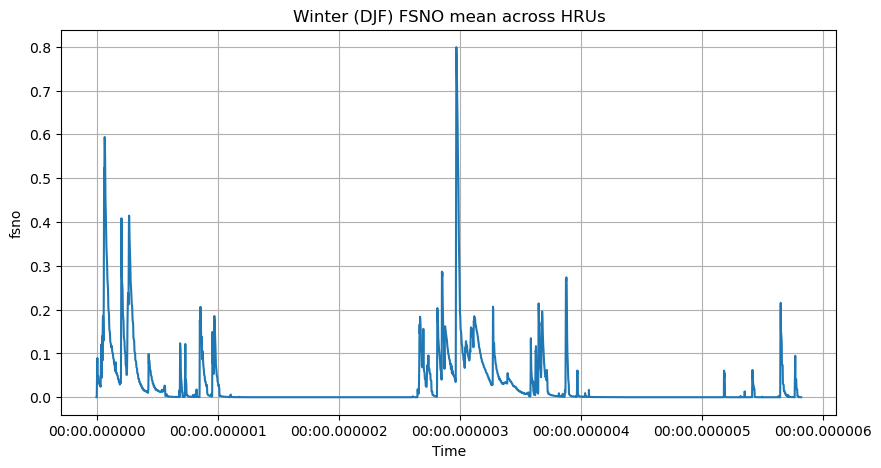

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# example file
file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"

ds = xr.open_dataset(file, group="data")

# choose variable, e.g. fsno, swe, snowh, t2mb
var = "fsno"

# convert to DataFrame
df = ds[var].to_pandas()   # rows=time, cols=hru

# mean across HRUs
ts = df.mean(axis=1, skipna=True)

# make datetime index if needed
ts.index = pd.to_datetime(ts.index)

# keep only winter months
winter = ts[ts.index.month.isin([12, 1, 2])]

# plot
plt.figure(figsize=(10,5))
plt.plot(winter.index, winter.values)
plt.xlabel("Time")
plt.ylabel(var)
plt.title(f"Winter (DJF) {var.upper()} mean across HRUs")
plt.grid(True)
plt.show()

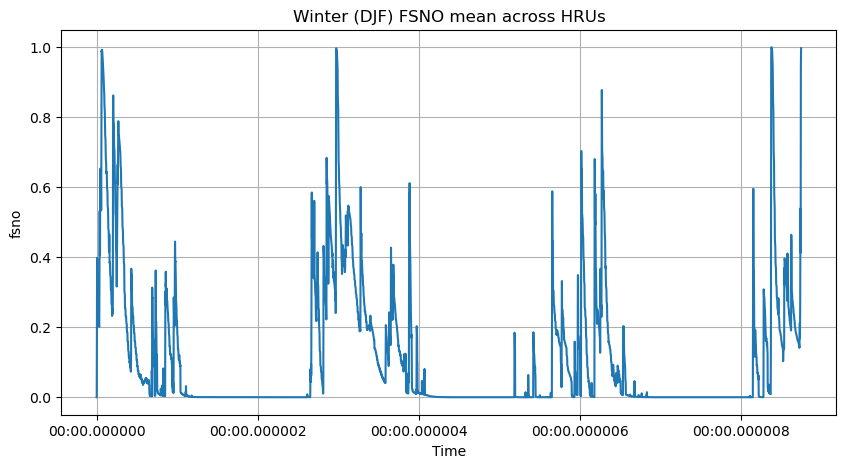

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# example file
file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"

ds = xr.open_dataset(file, group="data")

# choose variable, e.g. fsno, swe, snowh, t2mb
var = "fsno"

# convert to DataFrame
df = ds[var].to_pandas()   # rows=time, cols=hru

# mean across HRUs
ts = df.mean(axis=1, skipna=True)

# make datetime index if needed
ts.index = pd.to_datetime(ts.index)

# keep only winter months
winter = ts[ts.index.month.isin([12, 1, 2])]

# plot
plt.figure(figsize=(10,5))
plt.plot(winter.index, winter.values)
plt.xlabel("Time")
plt.ylabel(var)
plt.title(f"Winter (DJF) {var.upper()} mean across HRUs")
plt.grid(True)
plt.show()

count    5824.000000
mean        0.000633
std         0.574908
min        -0.975136
25%        -0.530647
50%         0.000976
75%         0.531295
max         0.975136
dtype: float64


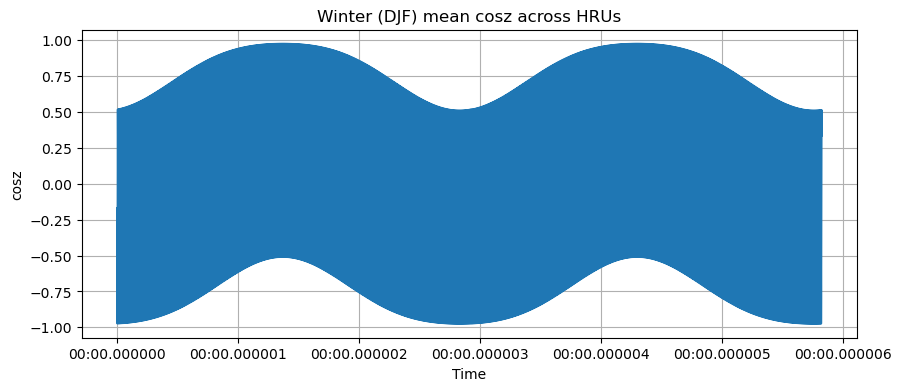

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# mean across HRUs
cosz_ts = ds["cosz"].to_pandas().mean(axis=1)

# make sure time index is datetime
cosz_ts.index = pd.to_datetime(cosz_ts.index)

# winter only
winter_cosz = cosz_ts[cosz_ts.index.month.isin([12, 1, 2])]

print(winter_cosz.describe())

plt.figure(figsize=(10,4))
plt.plot(winter_cosz.index, winter_cosz.values)
plt.xlabel("Time")
plt.ylabel("cosz")
plt.title("Winter (DJF) mean cosz across HRUs")
plt.grid(True)
plt.show()

count    804.000000
mean     277.732574
std      122.671227
min       18.006161
25%      164.474625
50%      261.774216
75%      379.698387
max      588.901855
dtype: float64


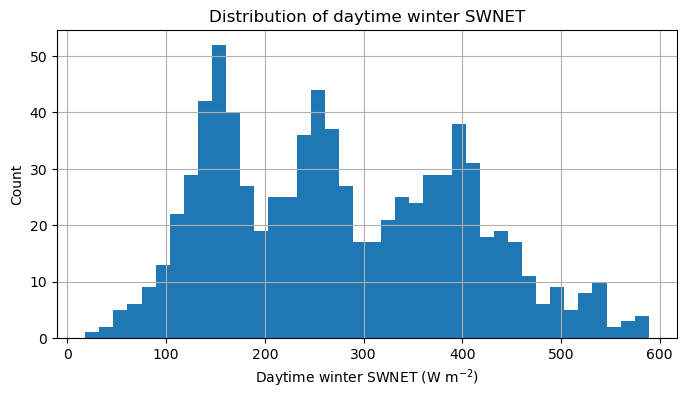

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

sw = ds["swnet"].to_pandas().mean(axis=1)

time_index = pd.date_range(
    start="2014-01-01 00:00:00",
    periods=len(sw),
    freq="3H"
)
sw.index = time_index

cosz = ds["cosz"].to_pandas().mean(axis=1)
cosz.index = time_index

# winter only
mask_winter = sw.index.month.isin([12, 1, 2])

# daytime only
mask_day = cosz > 0

winter_day_sw = sw[mask_winter & mask_day]

print(winter_day_sw.describe())

plt.figure(figsize=(8,4))
plt.hist(winter_day_sw.values, bins=40)
plt.xlabel("Daytime winter SWNET (W m$^{-2}$)")
plt.ylabel("Count")
plt.title("Distribution of daytime winter SWNET")
plt.grid(True)
plt.show()

In [6]:
swe = ds["swe"].to_pandas().mean(axis=1)

swe.index = time_index
winter_swe = swe[swe.index.month.isin([12,1,2])]

print(winter_swe.describe())

count    1424.000000
mean       13.591583
std        11.027717
min         0.000000
25%         1.925740
50%        12.784163
75%        24.320204
max        33.311897
dtype: float64


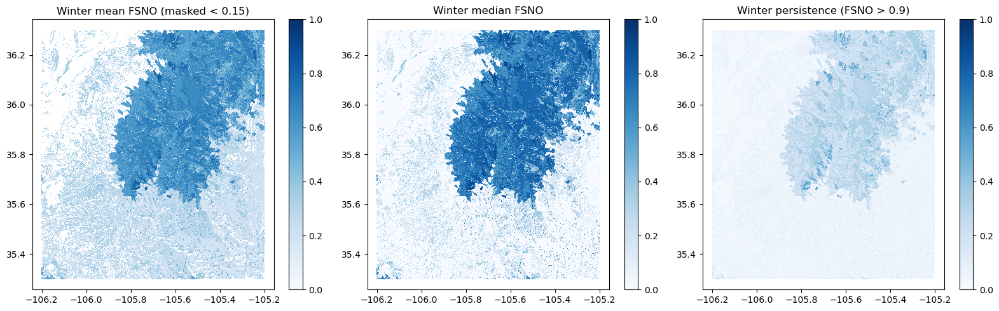

In [3]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots"
os.makedirs(outputdir, exist_ok=True)

path = path_pp   # use one consistent path

# ----------------------------
# Read time from SAME run
# ----------------------------
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

start = pd.Timestamp("2016-01-01 00:00:00")
times = start + pd.to_timedelta(time, unit="h")
times = pd.Series(times, name="datetime")   # keep simple, no tz conversion for now

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# ----------------------------
# Read FSNO
# ----------------------------
fp = nc.Dataset(path + "output_data/1/2016-01-01.nc")
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

# ----------------------------
# Winter mask
# ----------------------------
winter_mask = times.month.isin([12, 1, 2])
fsno_winter = fsno[winter_mask, :]

# Products
winter_mean = np.nanmean(fsno_winter, axis=0)
winter_mean[winter_mean < 0.15] = np.nan

winter_median = np.nanmedian(fsno_winter, axis=0)

winter_persist_08 = np.nanmean(fsno_winter > 0.8, axis=0)
winter_persist_09 = np.nanmean(fsno_winter > 0.9, axis=0)

products = [
    ("Winter mean FSNO (masked < 0.15)", winter_mean, 0.0, 1.0),
    ("Winter median FSNO", winter_median, 0.0, 1.0),
    ("Winter persistence (FSNO > 0.9)", winter_persist_09, 0.0, 1.0),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, vals, vmin, vmax) in zip(axes, products):
    final_map = place_data(tmp, vals, hrus, cids, 1)
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="Blues",
        norm=colors.Normalize(vmin=vmin, vmax=vmax),
        shading="auto"
    )
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "winter_fsno_mean_median_persistence_pp.png"), dpi=300)
plt.show()



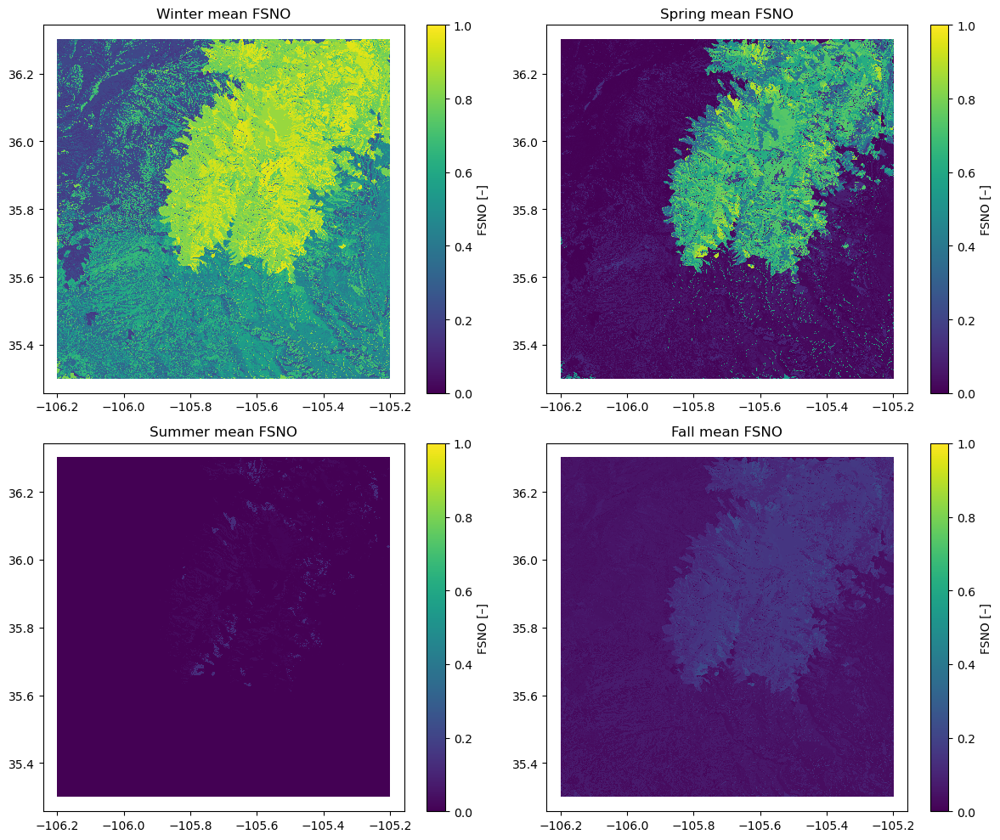

In [10]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

path = path_pp

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru >= 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# ----------------------------
# Read FSNO
# ----------------------------
fp = nc.Dataset(path + "output_data/1/2016-01-01.nc")
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 mean seasonal FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_array(final_map, final_map == -9999.0)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "seasonal_mean_fsno_pp_2x2.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

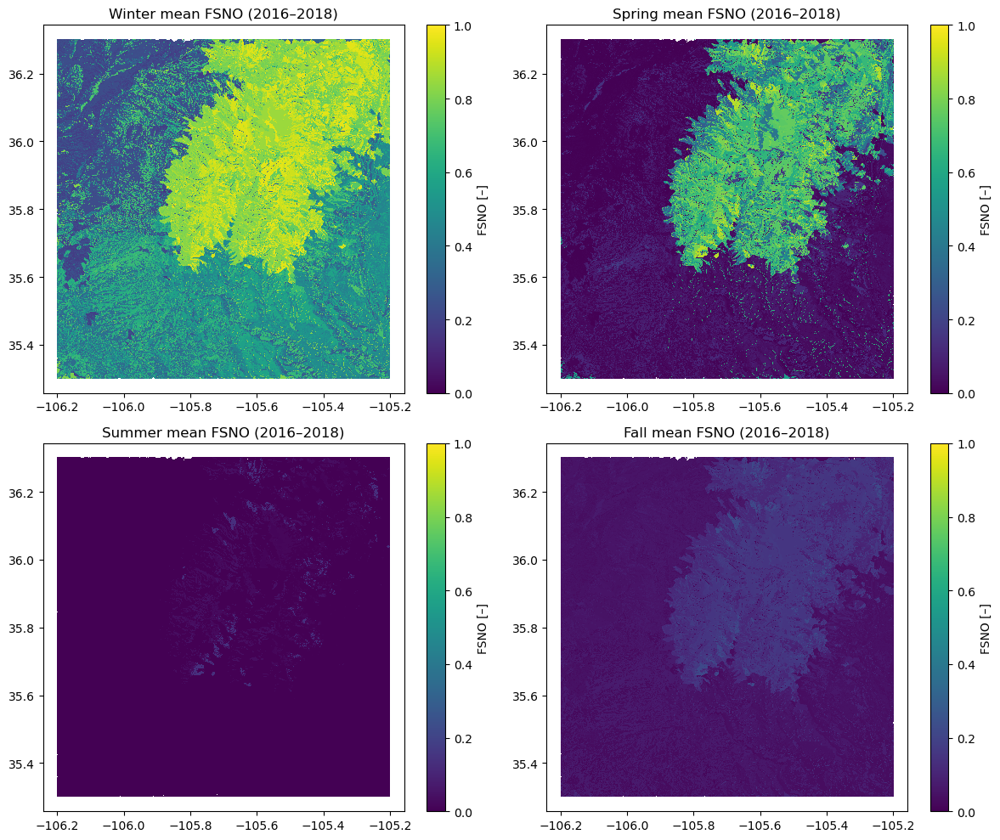

In [4]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# ----------------------------
# Read ALL daily files (2016–2018)
# ----------------------------
files = sorted(glob.glob(path_pp + "output_data/1/*.nc"))

fsno_list = []
time_list = []

for f in files:
    fp = nc.Dataset(f)
    grp = fp.groups["data"]
    fsno_day = np.array(grp.variables["fsno"][:])   # (time, hru)

    # parse date from filename
    day = pd.to_datetime(os.path.basename(f).replace(".nc", ""))

    # each daily file has 3-hourly steps
    ntime_day = fsno_day.shape[0]
    times_day = pd.date_range(day, periods=ntime_day, freq="3H")

    fsno_list.append(fsno_day)
    time_list.append(times_day)

    fp.close()

fsno = np.concatenate(fsno_list, axis=0)
times = pd.DatetimeIndex(np.concatenate(time_list))

# ----------------------------
# Restrict to 2016–2018
# ----------------------------
mask_period = (times >= "2016-01-01") & (times < "2019-01-01")
fsno = fsno[mask_period, :]
times = times[mask_period]

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_array(final_map, final_map == -9999.0)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "seasonal_mean_fsno_pp_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [6]:
import netCDF4 as nc
import pandas as pd

fp = nc.Dataset("/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc")
grp = fp.groups["data"]
ntime = grp.variables["fsno"].shape[0]
fp.close()

times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")
print(ntime, times.min(), times.max())

8744 2016-01-01 00:00:00 2018-12-28 21:00:00


In [5]:
print(fsno.shape)
print(times.min(), times.max())
for s, months in season_months.items():
    print(s, np.sum(times.month.isin(months)))

(17512, 1000)
2016-01-01 00:00:00 2018-12-31 21:00:00
Winter 4312
Spring 4416
Summer 4416
Fall 4368


(8744, 1000)
2016-01-01 00:00:00 2018-12-28 21:00:00


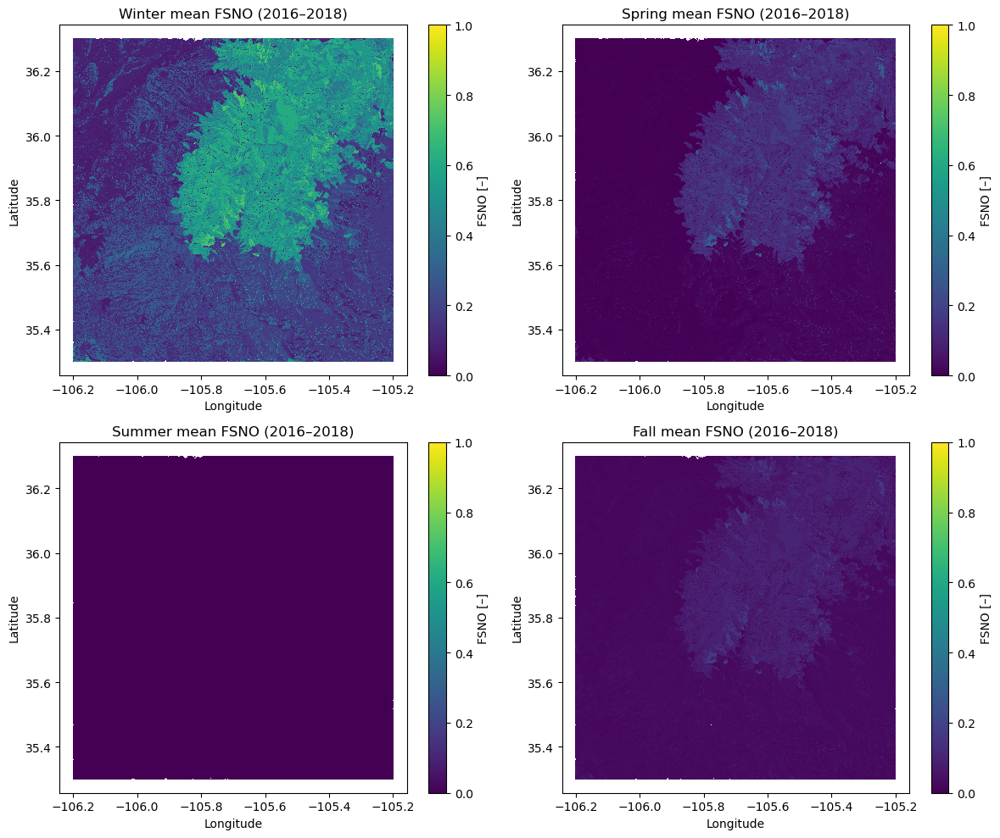

In [16]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# IMPORTANT:
# use ONLY the rerun file for 2016–2018, not all files in output_data/1
fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

# This file is already the 2016–2018 run:
ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print(fsno.shape)
print(times.min(), times.max())

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "seasonal_mean_fsno_2016_2018_singlefile.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

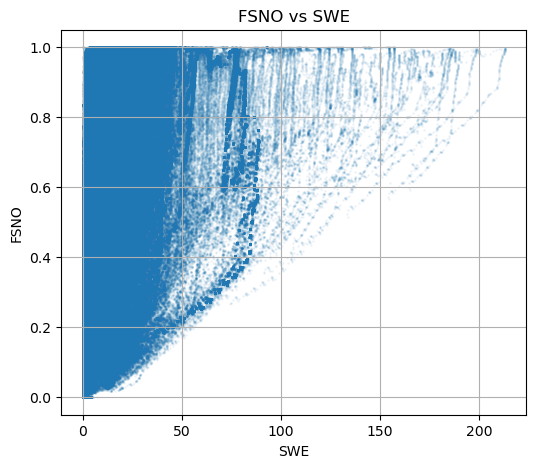

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
# example file
file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"

ds = xr.open_dataset(file, group="data")
swe = ds["swe"][:].values.flatten()
fsno = ds["fsno"][:].values.flatten()

mask = np.isfinite(swe) & np.isfinite(fsno)
swe = swe[mask]
fsno = fsno[mask]

plt.figure(figsize=(6,5))
plt.scatter(swe, fsno, s=1, alpha=0.05)
plt.xlabel("SWE")
plt.ylabel("FSNO")
plt.title("FSNO vs SWE")
plt.grid(True)
plt.show()

MSWX shape : (8744, 1000)
NLDAS shape: (8744, 1000)


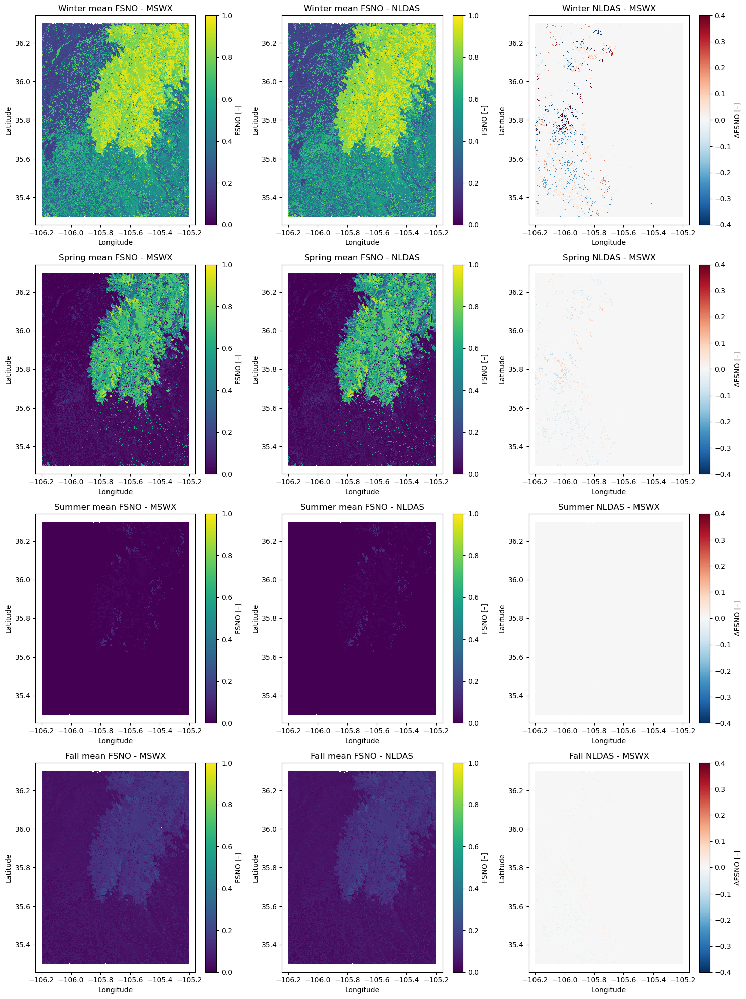

In [2]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# use only the clean 2016–2018 files
file_mswx  = path_mswx  + "output_data/1/2016-01-01.nc"
file_nldas = path_nldas + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters from one run
# ----------------------------
hrus = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:len(coord_yy0)-buffer+1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()
    return fsno

# ----------------------------
# Read FSNO
# ----------------------------
fsno_mswx = read_fsno(file_mswx)
fsno_nldas = read_fsno(file_nldas)

print("MSWX shape :", fsno_mswx.shape)
print("NLDAS shape:", fsno_nldas.shape)

# same 2016–2018 3-hourly timeline
ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot MSWX vs NLDAS vs Difference
# ----------------------------
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

for row, season in enumerate(seasons):
    mask = times.month.isin(season_months[season])

    mswx_mean = np.nanmean(fsno_mswx[mask, :], axis=0)
    nldas_mean = np.nanmean(fsno_nldas[mask, :], axis=0)
    diff_mean = nldas_mean - mswx_mean

    map_mswx = place_data(tmp, mswx_mean, hrus, cids, 1)
    map_nldas = place_data(tmp, nldas_mean, hrus, cids, 1)
    map_diff = place_data(tmp, diff_mean, hrus, cids, 1)

    map_mswx = np.ma.masked_where(map_mswx == -9999.0, map_mswx)
    map_nldas = np.ma.masked_where(map_nldas == -9999.0, map_nldas)
    map_diff = np.ma.masked_where(map_diff == -9999.0, map_diff)

    map_mswx = map_mswx[buffer:map_mswx.shape[0]-buffer+1,
                        buffer:map_mswx.shape[1]-buffer+1]
    map_nldas = map_nldas[buffer:map_nldas.shape[0]-buffer+1,
                          buffer:map_nldas.shape[1]-buffer+1]
    map_diff = map_diff[buffer:map_diff.shape[0]-buffer+1,
                        buffer:map_diff.shape[1]-buffer+1]

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x, coords_y, np.flipud(map_mswx),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"{season} mean FSNO - MSWX")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x, coords_y, np.flipud(map_nldas),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"{season} mean FSNO - NLDAS")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x, coords_y, np.flipud(map_diff),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"{season} NLDAS - MSWX")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "seasonal_fsno_MSWX_vs_NLDAS_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

MSWX fsno shape : (8744, 1000)
NLDAS fsno shape: (8744, 1000)
MSWX hrus shape : (1801, 1801)
NLDAS hrus shape: (1801, 1801)
Same plotting grid: True


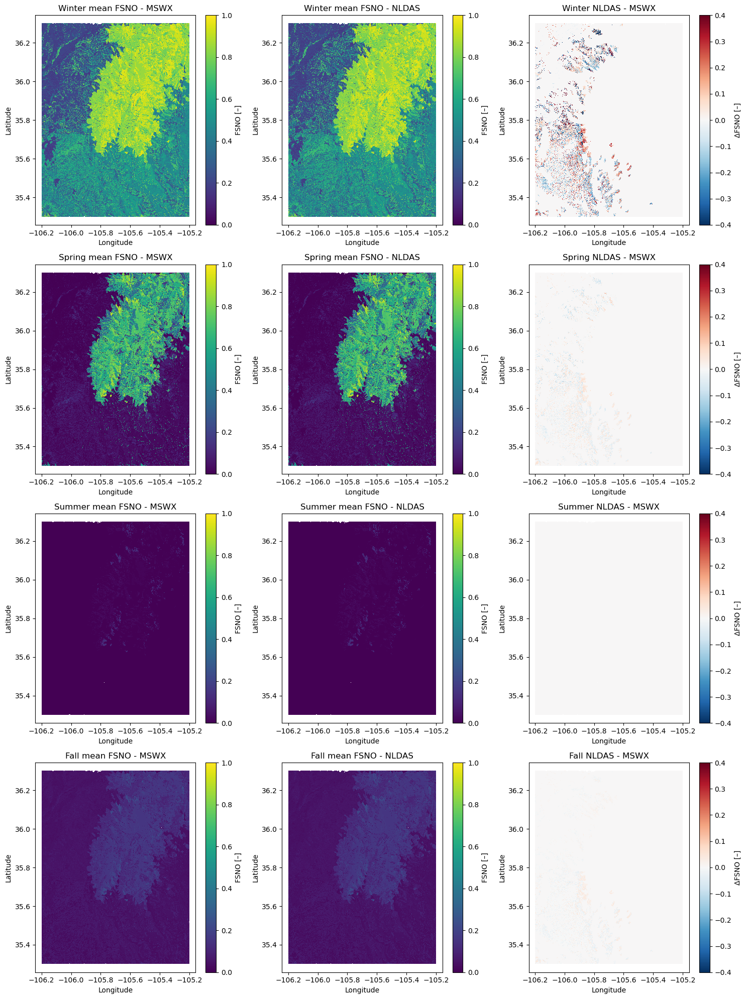

In [4]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# clean 2016 file
file_mswx  = path_mswx  + "output_data/1/2016-01-01.nc"
file_nldas = path_nldas + "output_data/1/2016-01-01.nc"


# HRU rasters
hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

hrus_nldas = gdal_tools.read_raster(path_nldas + "postprocess/hrus.vrt")
cids_nldas = gdal_tools.read_raster(path_nldas + "postprocess/cids.vrt")
meta_nldas = gdal_tools.retrieve_metadata(path_nldas + "postprocess/hrus.vrt")

buffer = 250

# forcing coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_nldas = np.linspace(meta_nldas["minx"], meta_nldas["maxx"], meta_nldas["nx"])
coord_yy0_nldas = np.linspace(meta_nldas["miny"], meta_nldas["maxy"], meta_nldas["ny"])
coords_x_nldas = coord_xx0_nldas[buffer:len(coord_xx0_nldas)-buffer+1]
coords_y_nldas = coord_yy0_nldas[buffer:len(coord_yy0_nldas)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_nldas = np.full(hrus_nldas.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()
    return fsno

# Read FSNO
fsno_mswx = read_fsno(file_mswx)
fsno_nldas = read_fsno(file_nldas)

print("MSWX fsno shape :", fsno_mswx.shape)
print("NLDAS fsno shape:", fsno_nldas.shape)
print("MSWX hrus shape :", hrus_mswx.shape)
print("NLDAS hrus shape:", hrus_nldas.shape)


# Check compatibility
if fsno_mswx.shape[1] != np.nanmax(hrus_mswx):
    print("Warning: MSWX HRU count may not match fsno HRU dimension")

if fsno_nldas.shape[1] != np.nanmax(hrus_nldas):
    print("Warning: NLDAS HRU count may not match fsno HRU dimension")

same_grid = (
    hrus_mswx.shape == hrus_nldas.shape and
    meta_mswx["minx"] == meta_nldas["minx"] and
    meta_mswx["maxx"] == meta_nldas["maxx"] and
    meta_mswx["miny"] == meta_nldas["miny"] and
    meta_mswx["maxy"] == meta_nldas["maxy"]
)

print("Same plotting grid:", same_grid)

# same 2016–2018 3-hourly timeline for both forcing
ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")


# Seasonal definitions
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# Plot MSWX vs NLDAS vs Difference
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

for row, season in enumerate(seasons):
    mask = times.month.isin(season_months[season])

    mswx_mean = np.nanmean(fsno_mswx[mask, :], axis=0)
    nldas_mean = np.nanmean(fsno_nldas[mask, :], axis=0)

    map_mswx = place_data(tmp_mswx, mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas = place_data(tmp_nldas, nldas_mean, hrus_nldas, cids_nldas, 1)

    map_mswx = np.ma.masked_where(map_mswx == -9999.0, map_mswx)
    map_nldas = np.ma.masked_where(map_nldas == -9999.0, map_nldas)

    map_mswx = map_mswx[buffer:map_mswx.shape[0]-buffer+1,
                        buffer:map_mswx.shape[1]-buffer+1]
    map_nldas = map_nldas[buffer:map_nldas.shape[0]-buffer+1,
                          buffer:map_nldas.shape[1]-buffer+1]

    # difference only safe if final mapped grids are same shape
    if map_mswx.shape != map_nldas.shape:
        raise ValueError(
            f"Mapped MSWX and NLDAS grids differ in shape: {map_mswx.shape} vs {map_nldas.shape}"
        )

    diff_mean = map_nldas - map_mswx

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"{season} mean FSNO - MSWX")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x_nldas, coords_y_nldas, np.flipud(map_nldas),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"{season} mean FSNO - NLDAS")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"{season} NLDAS - MSWX")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "seasonal_fsno_MSWX_vs_NLDAS_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [6]:
unique_hrus_mswx = np.unique(hrus_mswx[hrus_mswx > 0]).astype(int)
unique_hrus_nldas = np.unique(hrus_nldas[hrus_nldas > 0]).astype(int)

print("MSWX mapped HRUs :", len(unique_hrus_mswx))
print("NLDAS mapped HRUs:", len(unique_hrus_nldas))
print("MSWX fsno HRUs   :", fsno_mswx.shape[1])
print("NLDAS fsno HRUs  :", fsno_nldas.shape[1])

missing_mswx = sorted(set(range(1, fsno_mswx.shape[1] + 1)) - set(unique_hrus_mswx))
missing_nldas = sorted(set(range(1, fsno_nldas.shape[1] + 1)) - set(unique_hrus_nldas))

print("Missing MSWX HRUs from raster:", missing_mswx[:20])
print("Missing NLDAS HRUs from raster:", missing_nldas[:20])

MSWX mapped HRUs : 999
NLDAS mapped HRUs: 999
MSWX fsno HRUs   : 1000
NLDAS fsno HRUs  : 1000
Missing MSWX HRUs from raster: [1000]
Missing NLDAS HRUs from raster: [1000]


   season  MSWX_FSNO  NLDAS_FSNO  NLDAS_minus_MSWX
0  Winter   0.549836    0.550019          0.000183
1  Spring   0.189041    0.189071          0.000030
2  Summer   0.000724    0.000724          0.000000
3    Fall   0.076909    0.076968          0.000058


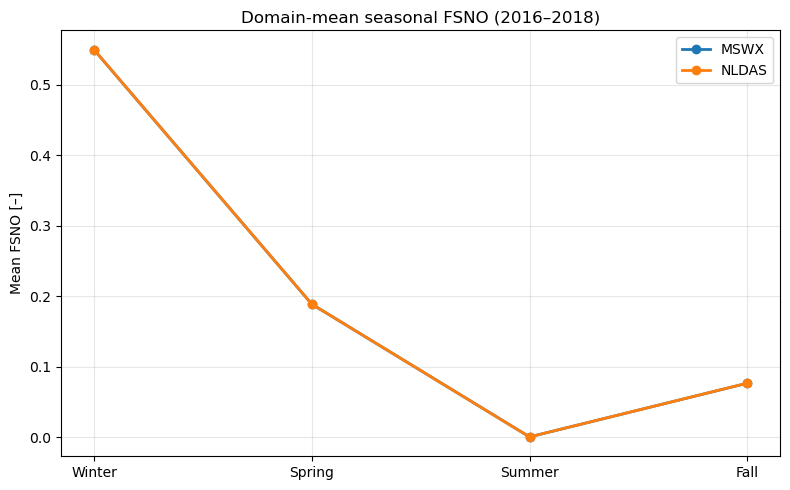

In [10]:
# ----------------------------
# Domain-mean seasonal FSNO summary
# ----------------------------
seasonal_summary = []

for season in seasons:
    mask = times.month.isin(season_months[season])
    mswx_val = np.nanmean(fsno_mswx[mask, :])
    nldas_val = np.nanmean(fsno_nldas[mask, :])
    seasonal_summary.append([season, mswx_val, nldas_val, nldas_val - mswx_val])

summary_df = pd.DataFrame(
    seasonal_summary,
    columns=["season", "MSWX_FSNO", "NLDAS_FSNO", "NLDAS_minus_MSWX"]
)

print(summary_df)

plt.figure(figsize=(8, 5))
plt.plot(summary_df["season"], summary_df["MSWX_FSNO"], marker="o", linewidth=2, label="MSWX")
plt.plot(summary_df["season"], summary_df["NLDAS_FSNO"], marker="o", linewidth=2, label="NLDAS")
plt.ylabel("Mean FSNO [–]")
plt.title("Domain-mean seasonal FSNO (2016–2018)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

/projects/battobrah@xsede.org/code-server/tmp/ipykernel_3880231/1159942854.py:42: RuntimeWarning: Mean of empty slice
  albedo_mean = np.nanmean(albedo, axis=1)


             SWE_MSWX  SWE_NLDAS  FSNO_MSWX  FSNO_NLDAS  ALB_MSWX  ALB_NLDAS
time                                                                        
2016-01-31   8.713304   8.717134   0.910560    0.910623  0.607413   0.607754
2016-02-29  17.740324  17.748257   0.672516    0.672417  0.608378   0.608471
2016-03-31   9.330424   9.328820   0.204310    0.204324  0.389477   0.389552
2016-04-30   7.521833   7.521791   0.233454    0.233430  0.243468   0.243537
2016-05-31   6.002531   6.002548   0.175365    0.175383  0.238174   0.238237


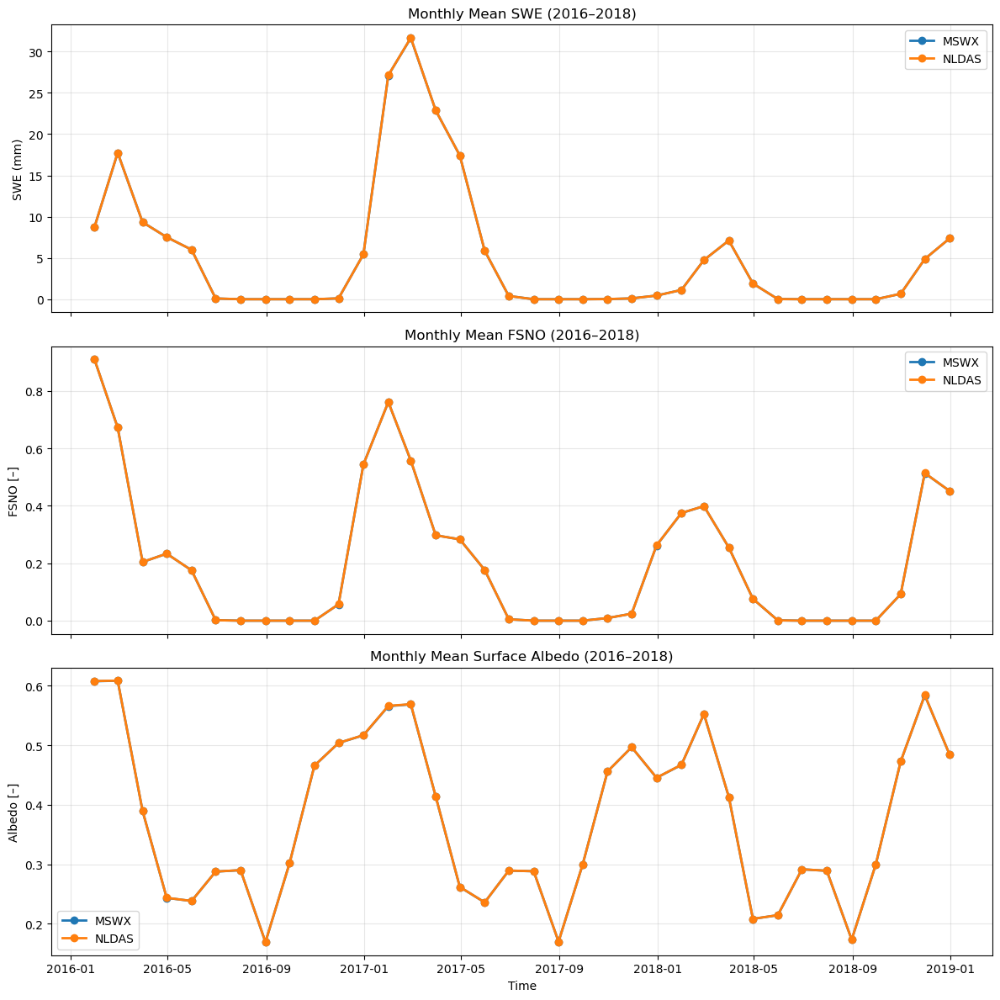

In [15]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------------
# Paths
# -----------------------------------
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/output_data/1/2016-01-01.nc"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# -----------------------------------
# Helper to read one run
# -----------------------------------
def read_run(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]

    swe = np.array(grp.variables["swe"][:], dtype=np.float32)      # (time, hru)
    fsno = np.array(grp.variables["fsno"][:], dtype=np.float32)    # (time, hru)

    # albedo proxy: use surface net shortwave / downward shortwave if available
    swdn = np.array(grp.variables["swdn"][:], dtype=np.float32)
    swnet = np.array(grp.variables["swnet"][:], dtype=np.float32)

    fp.close()

    # domain means
    swe_mean = np.nanmean(swe, axis=1)
    fsno_mean = np.nanmean(fsno, axis=1)

    # albedo = 1 - swnet / swdn
    # avoid division by zero
    albedo = np.full_like(swdn, np.nan, dtype=np.float32)
    good = swdn > 1e-6
    albedo[good] = 1.0 - (swnet[good] / swdn[good])

    albedo_mean = np.nanmean(albedo, axis=1)

    return swe_mean, fsno_mean, albedo_mean

# -----------------------------------
# Read both runs
# -----------------------------------
swe_mswx, fsno_mswx, alb_mswx = read_run(path_mswx)
swe_nldas, fsno_nldas, alb_nldas = read_run(path_nldas)

# -----------------------------------
# Time vector
# -----------------------------------
ntime = len(swe_mswx)
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

# -----------------------------------
# Monthly means
# -----------------------------------
df = pd.DataFrame({
    "time": times,
    "SWE_MSWX": swe_mswx,
    "SWE_NLDAS": swe_nldas,
    "FSNO_MSWX": fsno_mswx,
    "FSNO_NLDAS": fsno_nldas,
    "ALB_MSWX": alb_mswx,
    "ALB_NLDAS": alb_nldas,
}).set_index("time")

monthly = df.resample("M").mean()

print(monthly.head())

# -----------------------------------
# Plot
# -----------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# SWE
axes[0].plot(monthly.index, monthly["SWE_MSWX"], marker="o", linewidth=2, label="MSWX")
axes[0].plot(monthly.index, monthly["SWE_NLDAS"], marker="o", linewidth=2, label="NLDAS")
axes[0].set_ylabel("SWE (mm)")
axes[0].set_title("Monthly Mean SWE (2016–2018)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# FSNO
axes[1].plot(monthly.index, monthly["FSNO_MSWX"], marker="o", linewidth=2, label="MSWX")
axes[1].plot(monthly.index, monthly["FSNO_NLDAS"], marker="o", linewidth=2, label="NLDAS")
axes[1].set_ylabel("FSNO [–]")
axes[1].set_title("Monthly Mean FSNO (2016–2018)")
axes[1].grid(alpha=0.3)
axes[1].legend()

# Albedo
axes[2].plot(monthly.index, monthly["ALB_MSWX"], marker="o", linewidth=2, label="MSWX")
axes[2].plot(monthly.index, monthly["ALB_NLDAS"], marker="o", linewidth=2, label="NLDAS")
axes[2].set_ylabel("Albedo [–]")
axes[2].set_title("Monthly Mean Surface Albedo (2016–2018)")
axes[2].grid(alpha=0.3)
axes[2].legend()

axes[2].set_xlabel("Time")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "monthly_mean_SWE_FSNO_albedo_MSWX_vs_NLDAS.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

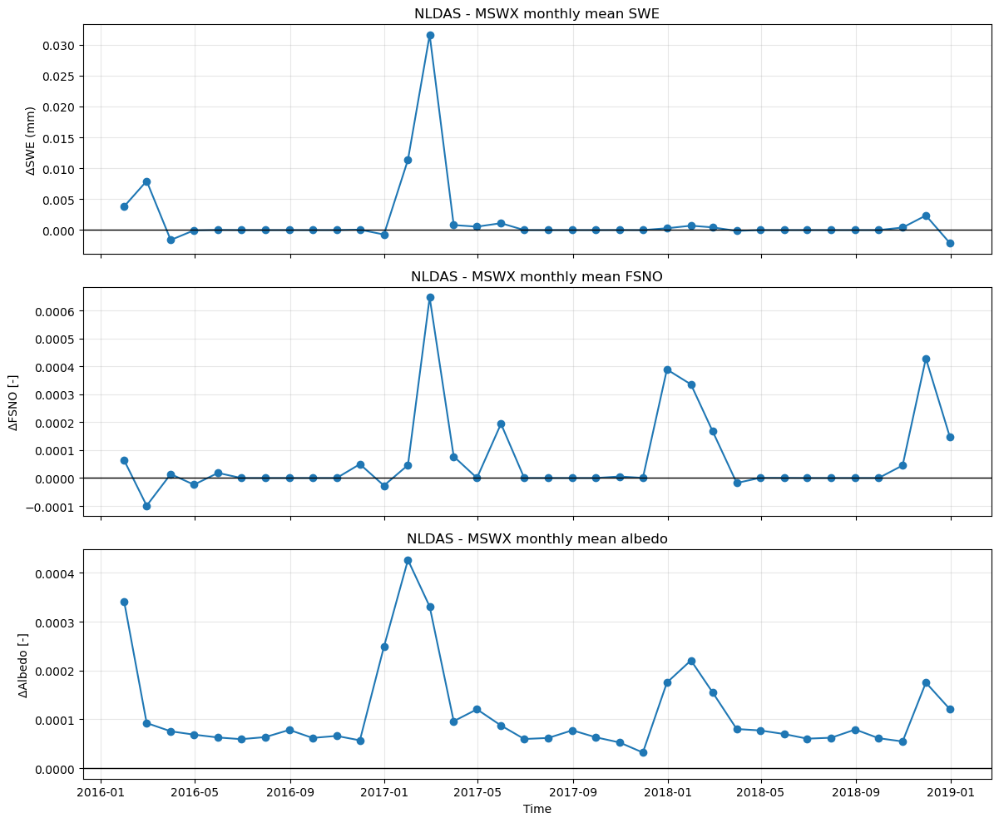

In [16]:
# differences
monthly["dSWE"]  = monthly["SWE_NLDAS"]  - monthly["SWE_MSWX"]
monthly["dFSNO"] = monthly["FSNO_NLDAS"] - monthly["FSNO_MSWX"]
monthly["dALB"]  = monthly["ALB_NLDAS"]  - monthly["ALB_MSWX"]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly.index, monthly["dSWE"], marker="o")
axes[0].axhline(0, color="k", linewidth=1)
axes[0].set_ylabel("ΔSWE (mm)")
axes[0].set_title("NLDAS - MSWX monthly mean SWE")

axes[1].plot(monthly.index, monthly["dFSNO"], marker="o")
axes[1].axhline(0, color="k", linewidth=1)
axes[1].set_ylabel("ΔFSNO [-]")
axes[1].set_title("NLDAS - MSWX monthly mean FSNO")

axes[2].plot(monthly.index, monthly["dALB"], marker="o")
axes[2].axhline(0, color="k", linewidth=1)
axes[2].set_ylabel("ΔAlbedo [-]")
axes[2].set_title("NLDAS - MSWX monthly mean albedo")
axes[2].set_xlabel("Time")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print("max |dSWE| :", np.nanmax(np.abs(monthly["dSWE"])))
print("max |dFSNO|:", np.nanmax(np.abs(monthly["dFSNO"])))
print("max |dALB| :", np.nanmax(np.abs(monthly["dALB"])))

max |dSWE| : 0.031570435
max |dFSNO|: 0.0006466508
max |dALB| : 0.00042629242


In [13]:
import numpy as np

print(np.allclose(swe_mswx, swe_nldas))
print(np.allclose(fsno_mswx, fsno_nldas))

False
False


In [26]:
import numpy as np
import rasterio
import geospatialtools.gdal_tools as gdal_tools

# ---------------------------------------------------
# Paths
# ---------------------------------------------------
cids_file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/postprocess/cids.vrt"
hrus_file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/postprocess/hrus.vrt"

modscag_file = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

# ---------------------------------------------------
# Read HydroBlocks HRU / cluster map
# ---------------------------------------------------
cids = np.array(gdal_tools.read_raster(cids_file).data).astype(int)
hrus = np.array(gdal_tools.read_raster(hrus_file).data).astype(int)

# valid HydroBlocks cells
valid_model = hrus > 0

# ---------------------------------------------------
# Read MODSCAG raster
# ---------------------------------------------------
with rasterio.open(modscag_file) as src:
    modscag = src.read(1).astype(float)
    nodata = src.nodata

# nodata handling
if nodata is not None:
    modscag[modscag == nodata] = np.nan

# ---------------------------------------------------
# Convert MODSCAG to fraction if needed
# ---------------------------------------------------
# adjust this depending on your file
# if MODSCAG is 0-100:
if np.nanmax(modscag) > 1.5:
    modscag = modscag / 100.0

# keep only physically valid range
modscag[(modscag < 0) | (modscag > 1)] = np.nan

# mask to model domain
modscag[~valid_model] = np.nan

# ---------------------------------------------------
# Aggregate MODSCAG to HRU means
# ---------------------------------------------------
def grid_to_hru_mean(grid, cids):
    """
    grid : 2D array on HydroBlocks grid
    cids : 2D integer cluster/HRU ID map
    returns:
        hru_ids   : sorted unique HRU ids
        hru_means : mean grid value in each HRU
    """
    valid = np.isfinite(grid) & (cids > 0)
    hru_ids = np.unique(cids[valid])
    hru_means = np.full(hru_ids.shape, np.nan, dtype=float)

    for i, hid in enumerate(hru_ids):
        vals = grid[(cids == hid) & np.isfinite(grid)]
        if vals.size > 0:
            hru_means[i] = np.nanmean(vals)

    return hru_ids, hru_means

hru_ids, modscag_hru = grid_to_hru_mean(modscag, cids)

print("Number of HRUs with MODSCAG data:", len(hru_ids))
print("First few HRU means:", modscag_hru[:10])

RasterioIOError: '/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL' not recognized as a supported file format.

In [24]:
# HRU-scale comparison: PP FSNO vs MODSCAG aggregated to HRUs
# This compares model snow cover and MODSCAG at the same HRU support

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geospatialtools.gdal_tools as gdal_tools

print("PP:", path_pp)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

# ----------------------------
# use PP domain for mapping
# ----------------------------
path = path_pp

# ----------------------------
# read mapping rasters
# ----------------------------
hrus = np.squeeze(np.array(gdal_tools.read_raster(path + "postprocess/hrus.vrt").data)).astype(int)
cids = np.squeeze(np.array(gdal_tools.read_raster(path + "postprocess/cids.vrt").data)).astype(int)

# valid model cells
valid_model = hrus > 0

# ----------------------------
# read time from PP run
# ----------------------------
fp = nc.Dataset(path_pp + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

start = pd.Timestamp("2016-01-01 00:00:00")
times = start + pd.to_timedelta(time, unit="h")   # DatetimeIndex

# ----------------------------
# seasons
# ----------------------------
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# ----------------------------
# MODSCAG monthly files
# ----------------------------
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = np.squeeze(da.values).astype("float32")
    ds.close()

    # convert % -> fraction
    arr = arr / 100.0

    # keep only valid range
    arr[(arr < 0) | (arr > 1)] = np.nan

    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

# ----------------------------
# grid -> HRU mean
# ----------------------------
def grid_to_hru_mean(grid, cids, valid_mask=None):
    grid = np.squeeze(grid)
    cids = np.squeeze(cids)

    if valid_mask is None:
        valid = np.isfinite(grid) & (cids > 0)
    else:
        valid = np.isfinite(grid) & (cids > 0) & valid_mask

    nhru = int(np.nanmax(cids))
    out = np.full(nhru, np.nan, dtype=float)

    hru_ids = np.unique(cids[valid]).astype(int)
    for hid in hru_ids:
        vals = grid[(cids == hid) & valid]
        if vals.size > 0:
            out[hid - 1] = np.nanmean(vals)

    return out

# ----------------------------
# optional: place HRU values back on grid
# ----------------------------
def place_hru_on_grid(hru_values, cids):
    cids = np.squeeze(cids)
    out = np.full(cids.shape, np.nan, dtype=float)
    ids = np.unique(cids[cids > 0]).astype(int)
    for hid in ids:
        if hid - 1 < len(hru_values):
            out[cids == hid] = hru_values[hid - 1]
    return out

# ----------------------------
# build MODSCAG file list
# ----------------------------
modscag_rows = build_modscag_rows(modscag_sat)

# ----------------------------
# read model fsno once
# ----------------------------
fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
grp_pp = fp_pp.groups["data"]
fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
fp_pp.close()

print("hrus shape:", hrus.shape)
print("cids shape:", cids.shape)
print("fsno_pp shape:", fsno_pp.shape)

# ----------------------------
# compare by season
# ----------------------------
for iss, my_season in enumerate(seasons):
    my_months = season_months[iss]
    print(f"\nSeason: {my_season}")

    # model seasonal mean in HRU space
    times_index = np.isin(times.month, my_months)
    fsno_pp_sel = fsno_pp[times_index, :]
    fsno_pp_ave = np.nanmean(fsno_pp_sel, axis=0)   # (hru,)

    # MODSCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        print("  No MODSCAG data")
        continue

    print("  modscag_map shape:", modscag_map.shape)

    # restrict to valid model cells
    modscag_map[~valid_model] = np.nan

    # aggregate MODSCAG to HRU means
    modscag_hru = grid_to_hru_mean(modscag_map, cids, valid_mask=valid_model)

    print("  fsno_pp_ave shape:", fsno_pp_ave.shape)
    print("  modscag_hru shape:", modscag_hru.shape)

    # make sure both arrays align
    nhru = min(len(fsno_pp_ave), len(modscag_hru))
    model_hru = fsno_pp_ave[:nhru]
    obs_hru   = modscag_hru[:nhru]

    # valid comparison mask
    valid = np.isfinite(model_hru) & np.isfinite(obs_hru)

    print("  Number of valid HRUs:", np.sum(valid))
    print("  Mean model FSNO:", np.nanmean(model_hru[valid]))
    print("  Mean MODSCAG HRU fSCA:", np.nanmean(obs_hru[valid]))
    print("  Mean bias (model - MODSCAG):", np.nanmean(model_hru[valid] - obs_hru[valid]))

    if np.sum(valid) > 2:
        corr = np.corrcoef(obs_hru[valid], model_hru[valid])[0, 1]
        print("  Spatial correlation:", corr)

    # scatter
    plt.figure(figsize=(6, 6))
    plt.scatter(obs_hru[valid], model_hru[valid], s=8, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("MODSCAG HRU-mean fSCA")
    plt.ylabel("Model HRU-mean FSNO")
    plt.title(f"HRU-scale comparison | {my_season}")
    plt.grid(True)
    plt.show()

    # optional HRU-support maps
    modscag_hru_map = place_hru_on_grid(obs_hru, cids)
    model_hru_map   = place_hru_on_grid(model_hru, cids)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(modscag_hru_map, origin="upper")
    plt.title(f"MODSCAG aggregated to HRUs | {my_season}")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(model_hru_map, origin="upper")
    plt.title(f"Model FSNO on HRUs | {my_season}")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL


OSError: [Errno -101] NetCDF: HDF error: b'/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp//output_data/1/2016-01-01.nc'

PP path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
hrus shape: (1801, 1801)
cids shape: (1801, 1801)
unique cids: [-9999     1] ...
MSWX shape: (8744, 1000)
MODSCAG 2016 months found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Season: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1475540/3741192239.py:112: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


  Number of valid HRUs: 999
  Mean model FSNO: 0.5512820984413788
  Mean MODSCAG HRU fSCA: 0.1671102314711305
  Mean bias: 0.38417186697024824
  RMSE: 0.43158585066432864
  Corr: 0.7204542719128166


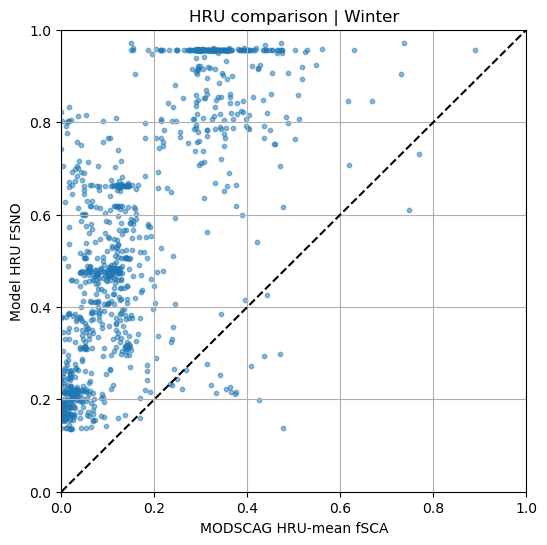

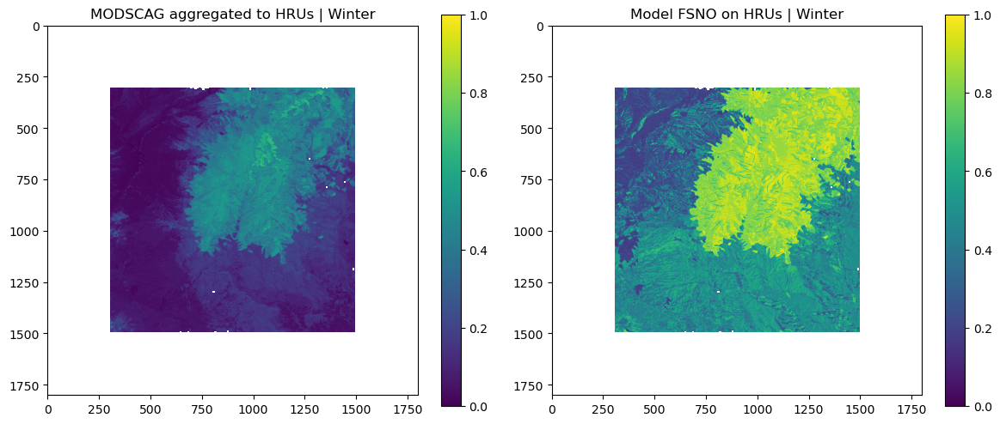


Season: Spring
  Number of valid HRUs: 999
  Mean model FSNO: 0.18746596063161197
  Mean MODSCAG HRU fSCA: 0.015126193100920903
  Mean bias: 0.17233976753069108
  RMSE: 0.31317868276307226
  Corr: 0.32696656559641946


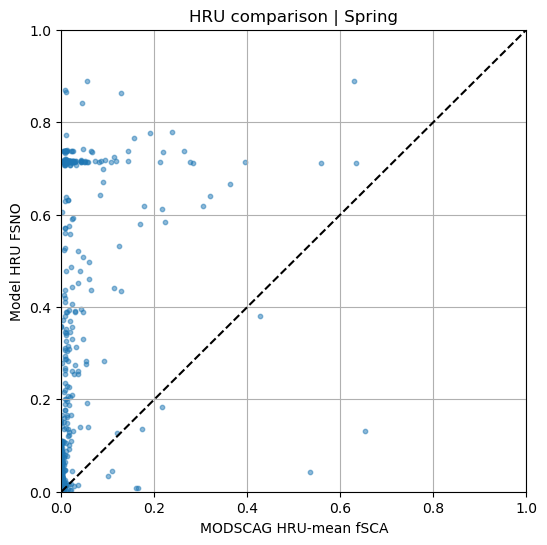

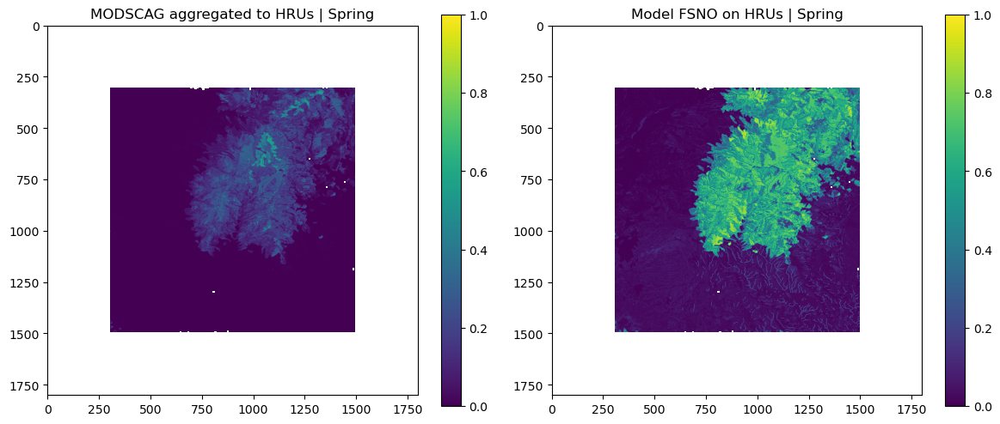


Season: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1475540/3741192239.py:112: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


  Number of valid HRUs: 999
  Mean model FSNO: 0.000707438765103277
  Mean MODSCAG HRU fSCA: 0.0002843764670115801
  Mean bias: 0.00042306229809169687
  RMSE: 0.007246315002621393
  Corr: 0.2576001703505896


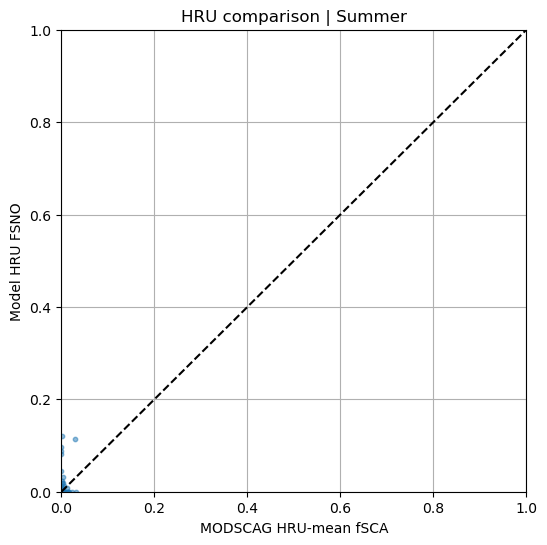

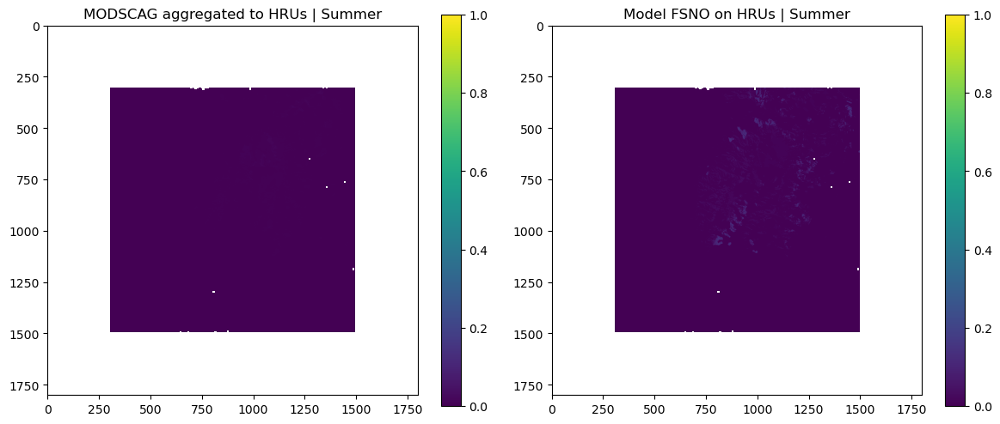


Season: Fall
  Number of valid HRUs: 999
  Mean model FSNO: 0.07805258496133487
  Mean MODSCAG HRU fSCA: 0.017638593229016956
  Mean bias: 0.06041399173231791
  RMSE: 0.07092712817705814
  Corr: 0.7028771343734851


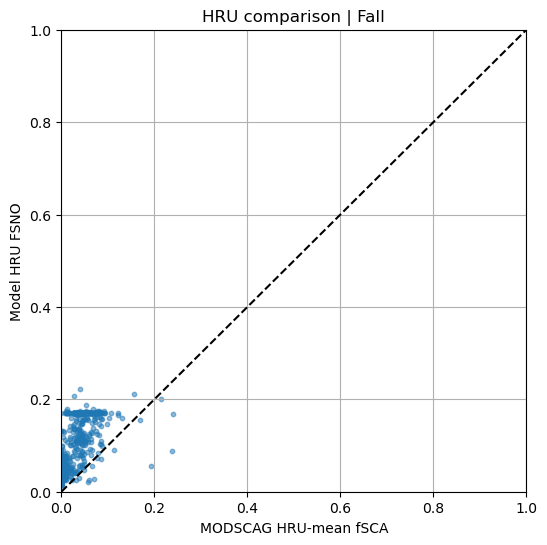

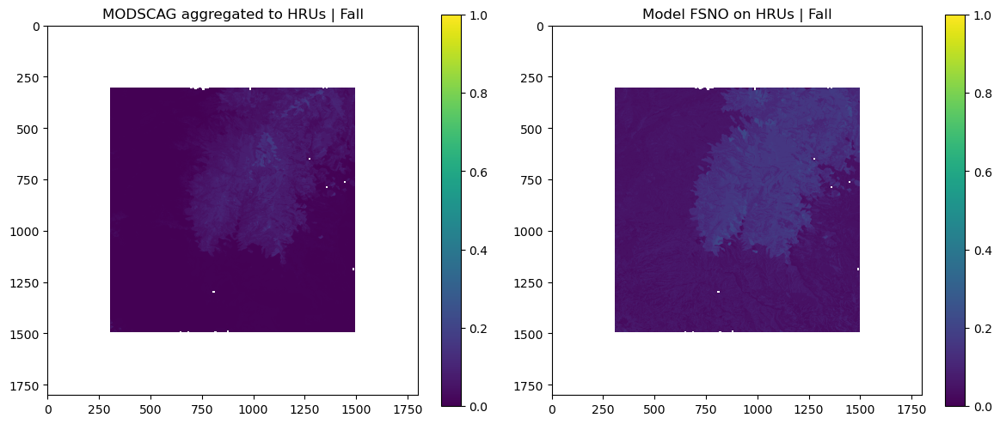



   Season   PP_mean  MODSCAG_mean  Bias_mean      RMSE      Corr
0  Winter  0.551282      0.167110   0.384172  0.431586  0.720454
1  Spring  0.187466      0.015126   0.172340  0.313179  0.326967
2  Summer  0.000707      0.000284   0.000423  0.007246  0.257600
3    Fall  0.078053      0.017639   0.060414  0.070927  0.702877


In [4]:
# ============================================================
# STEP 1: MODSCAG -> HRU comparison
# Compare model FSNO and MODSCAG at the same HRU support
# ============================================================

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

print("PP path:", path_pp)
print("MODSCAG:", modscag_sat)

# ----------------------------
# read time from model input
# ----------------------------
fp = nc.Dataset(path_pp + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since 2016-01-01
fp.close()

start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ----------------------------
# read HRU / CID maps
# ----------------------------
hrus = np.squeeze(np.array(gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt").data)).astype(int)
cids = np.squeeze(np.array(gdal_tools.read_raster(path_pp + "postprocess/cids.vrt").data)).astype(int)

print("hrus shape:", hrus.shape)
print("cids shape:", cids.shape)
print("unique cids:", np.unique(cids)[:20], "...")

valid_model = hrus > 0

# ----------------------------
# model HRU count
# ----------------------------
with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as ds:
    fsno_pp = np.array(ds.groups["data"].variables["fsno"][:]).astype(float)

# clean FSNO
fsno_pp[(fsno_pp < 0) | (fsno_pp > 1)] = np.nan

print("MSWX shape:", fsno_pp.shape)

# ----------------------------
# seasons
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ----------------------------
# MODSCAG file finder
# ----------------------------
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched in {modscag_folder}")
    return rows

def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = np.squeeze(da.values).astype(np.float32)
    ds.close()

    # convert percent -> fraction
    arr = arr / 100.0

    # clean range
    arr[(arr < 0) | (arr > 1)] = np.nan
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_modscag_grid(fp))
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

# ----------------------------
# grid -> HRU mean
# ----------------------------
def grid_to_hru_mean(grid, hrus, valid_mask=None):
    grid = np.squeeze(grid)
    hrus = np.squeeze(hrus)

    nhru = int(np.nanmax(hrus))
    out = np.full(nhru, np.nan, dtype=float)

    if valid_mask is None:
        valid = np.isfinite(grid) & (hrus > 0)
    else:
        valid = np.isfinite(grid) & (hrus > 0) & valid_mask

    ids = np.unique(hrus[valid]).astype(int)
    for hid in ids:
        vals = grid[(hrus == hid) & valid]
        if vals.size > 0:
            out[hid - 1] = np.nanmean(vals)

    return out

# optional: HRU back to grid for fair-looking HRU-support maps
def place_hru_on_grid(hru_values, hrus):
    out = np.full(hrus.shape, np.nan, dtype=float)
    ids = np.unique(hrus[hrus > 0]).astype(int)
    for hid in ids:
        if hid - 1 < len(hru_values):
            out[hrus == hid] = hru_values[hid - 1]
    return out

# ----------------------------
# build MODSCAG list
# ----------------------------
modscag_rows = build_modscag_rows(modscag_sat)
print("MODSCAG 2016 months found:", [dt.month for dt, _ in modscag_rows if dt.year == 2016])

# ----------------------------
# results table
# ----------------------------
rows_out = []

for my_season, my_months in zip(seasons, season_months):
    print("\nSeason:", my_season)

    # model seasonal mean in HRU space
    times_index = np.isin(times.dt.month, my_months)
    fsno_sel = fsno_pp[times_index, :]
    fsno_hru = np.nanmean(fsno_sel, axis=0)

    # MODSCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        print("  No MODSCAG data")
        continue

    # keep only model domain
    modscag_map[~valid_model] = np.nan

    # aggregate MODSCAG to HRUs
    modscag_hru = grid_to_hru_mean(modscag_map, hrus, valid_mask=valid_model)

    # align
    nhru = min(len(fsno_hru), len(modscag_hru))
    fsno_hru = fsno_hru[:nhru]
    modscag_hru = modscag_hru[:nhru]

    valid = np.isfinite(fsno_hru) & np.isfinite(modscag_hru)

    pp_mean = np.nanmean(fsno_hru[valid])
    mod_mean = np.nanmean(modscag_hru[valid])
    bias = np.nanmean(fsno_hru[valid] - modscag_hru[valid])
    rmse = np.sqrt(np.nanmean((fsno_hru[valid] - modscag_hru[valid])**2))
    corr = np.corrcoef(modscag_hru[valid], fsno_hru[valid])[0, 1] if np.sum(valid) > 2 else np.nan

    print("  Number of valid HRUs:", np.sum(valid))
    print("  Mean model FSNO:", pp_mean)
    print("  Mean MODSCAG HRU fSCA:", mod_mean)
    print("  Mean bias:", bias)
    print("  RMSE:", rmse)
    print("  Corr:", corr)

    rows_out.append([my_season, pp_mean, mod_mean, bias, rmse, corr])

    # scatter
    plt.figure(figsize=(6, 6))
    plt.scatter(modscag_hru[valid], fsno_hru[valid], s=10, alpha=0.5)
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("MODSCAG HRU-mean fSCA")
    plt.ylabel("Model HRU FSNO")
    plt.title(f"HRU comparison | {my_season}")
    plt.grid(True)
    plt.show()

    # optional fair-support maps
    modscag_hru_map = place_hru_on_grid(modscag_hru, hrus)
    fsno_hru_map = place_hru_on_grid(fsno_hru, hrus)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(modscag_hru_map, origin="upper", vmin=0, vmax=1)
    plt.title(f"MODSCAG aggregated to HRUs | {my_season}")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(fsno_hru_map, origin="upper", vmin=0, vmax=1)
    plt.title(f"Model FSNO on HRUs | {my_season}")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# ----------------------------
# summary table
# ----------------------------
df_out = pd.DataFrame(rows_out, columns=["Season", "PP_mean", "MODSCAG_mean", "Bias_mean", "RMSE", "Corr"])
print("\n")
print(df_out)